In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('consumption_temp.csv')
df.head()

,time,location,consumption,temperature
0,2022-04-07 21:00:00,bergen,1.113325,-0.3
1,2022-04-07 21:00:00,oslo,4.092830,1.0
2,2022-04-07 21:00:00,stavanger,2.057858,1.3
3,2022-04-07 21:00:00,tromsø,1.246582,-3.9
4,2022-04-07 21:00:00,trondheim,1.970098,-2.8


In [3]:
df['time'] = pd.to_datetime(df['time'])
print(df.info())
print(df.isnull().sum())
print(f"\nNumber of duplicate rows: {df.duplicated().sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49494 entries, 0 to 49493
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   time         49494 non-null  datetime64[ns]
 1   location     49494 non-null  object        
 2   consumption  49494 non-null  float64       
 3   temperature  49494 non-null  float64       
dtypes: datetime64[ns](1), float64(2), object(1)
memory usage: 1.5+ MB
None
time           0
location       0
consumption    0
temperature    0
dtype: int64

Number of duplicate rows: 0


In [4]:
# count unique locations
print(f"Number of unique locations: {df['location'].nunique()}")

# print unique values in 'location' column
print(f"Unique locations: {df['location'].unique()}")

# create subsets for each location
df_bergen = df[df['location'] == 'bergen']
df_oslo = df[df['location'] == 'oslo']
df_stavanger = df[df['location'] == 'stavanger']
df_tromso = df[df['location'] == 'tromsø']
df_trondheim = df[df['location'] == 'trondheim']
df_helsingfors = df[df['location'] == 'helsingfors']

# show the history range, first datetime to last datetime for each location
print(f"Bergen date range: {df_bergen['time'].min()} to {df_bergen['time'].max()}")
print(f"Oslo date range: {df_oslo['time'].min()} to {df_oslo['time'].max()}")
print(f"Stavanger date range: {df_stavanger['time'].min()} to {df_stavanger['time'].max()}")
print(f"Tromsø date range: {df_tromso['time'].min()} to {df_tromso['time'].max()}")
print(f"Trondheim date range: {df_trondheim['time'].min()} to {df_trondheim['time'].max()}")
print(f"Helsingfors date range: {df_helsingfors['time'].min()} to {df_helsingfors['time'].max()}")

print("(ex.) Bergen history length:", len(df_bergen))
df_bergen.head()

Number of unique locations: 6
Unique locations: ['bergen' 'oslo' 'stavanger' 'tromsø' 'trondheim' 'helsingfors']
Bergen date range: 2022-04-07 21:00:00 to 2023-04-02 21:00:00
Oslo date range: 2022-04-07 21:00:00 to 2023-04-02 21:00:00
Stavanger date range: 2022-04-07 21:00:00 to 2023-04-02 21:00:00
Tromsø date range: 2022-04-07 21:00:00 to 2023-04-02 21:00:00
Trondheim date range: 2022-04-07 21:00:00 to 2023-04-02 21:00:00
Helsingfors date range: 2022-07-14 21:00:00 to 2023-04-02 21:00:00
(ex.) Bergen history length: 8641


,time,location,consumption,temperature
0,2022-04-07 21:00:00,bergen,1.113325,-0.3
5,2022-04-07 22:00:00,bergen,1.050327,0.0
10,2022-04-07 23:00:00,bergen,1.008794,-0.5
15,2022-04-08 00:00:00,bergen,0.984202,-1.1
20,2022-04-08 01:00:00,bergen,0.950335,-0.7


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ---------- Plot style ----------
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.color": "#D9D9D9",
    "grid.alpha": 0.35,
    "grid.linewidth": 0.7,
})

# ---------- Collect dataframes ----------
location_dfs = {
    "Bergen": df_bergen.copy(),
    "Oslo": df_oslo.copy(),
    "Stavanger": df_stavanger.copy(),
    "Tromsø": df_tromso.copy(),
    "Trondheim": df_trondheim.copy(),
    "Helsingfors": df_helsingfors.copy(),
}

# Ensure datetime dtype and add location name
for loc, d in location_dfs.items():
    d["time"] = pd.to_datetime(d["time"])
    d["location"] = loc

# Long dataframe for easier plotting
df_long = pd.concat(location_dfs.values(), ignore_index=True)

# Consistent color mapping across all figures
location_colors = {
    "Bergen":      "#08306b",  # very dark blue
    "Oslo":        "#08519c",  # dark blue
    "Stavanger":   "#2171b5",  # medium-dark blue
    "Tromsø":      "#4292c6",  # medium blue
    "Trondheim":   "#6baed6",  # light-medium blue
    "Helsingfors": "#9ecae1",  # light blue
}
pred_colors = {
    "PREDICTION_COLOR": "#b22222",      # firebrick
    "BASELINE_COLOR": "#7f7f7f",        # gray
    "ROLLING_MEAN_COLOR": "#222222",    # near black
    "REFERENCE_LINE_COLOR": "#666666"
}
# Monthly tick formatting
month_locator = mdates.MonthLocator(interval=2)
month_fmt = mdates.DateFormatter("%b %Y")

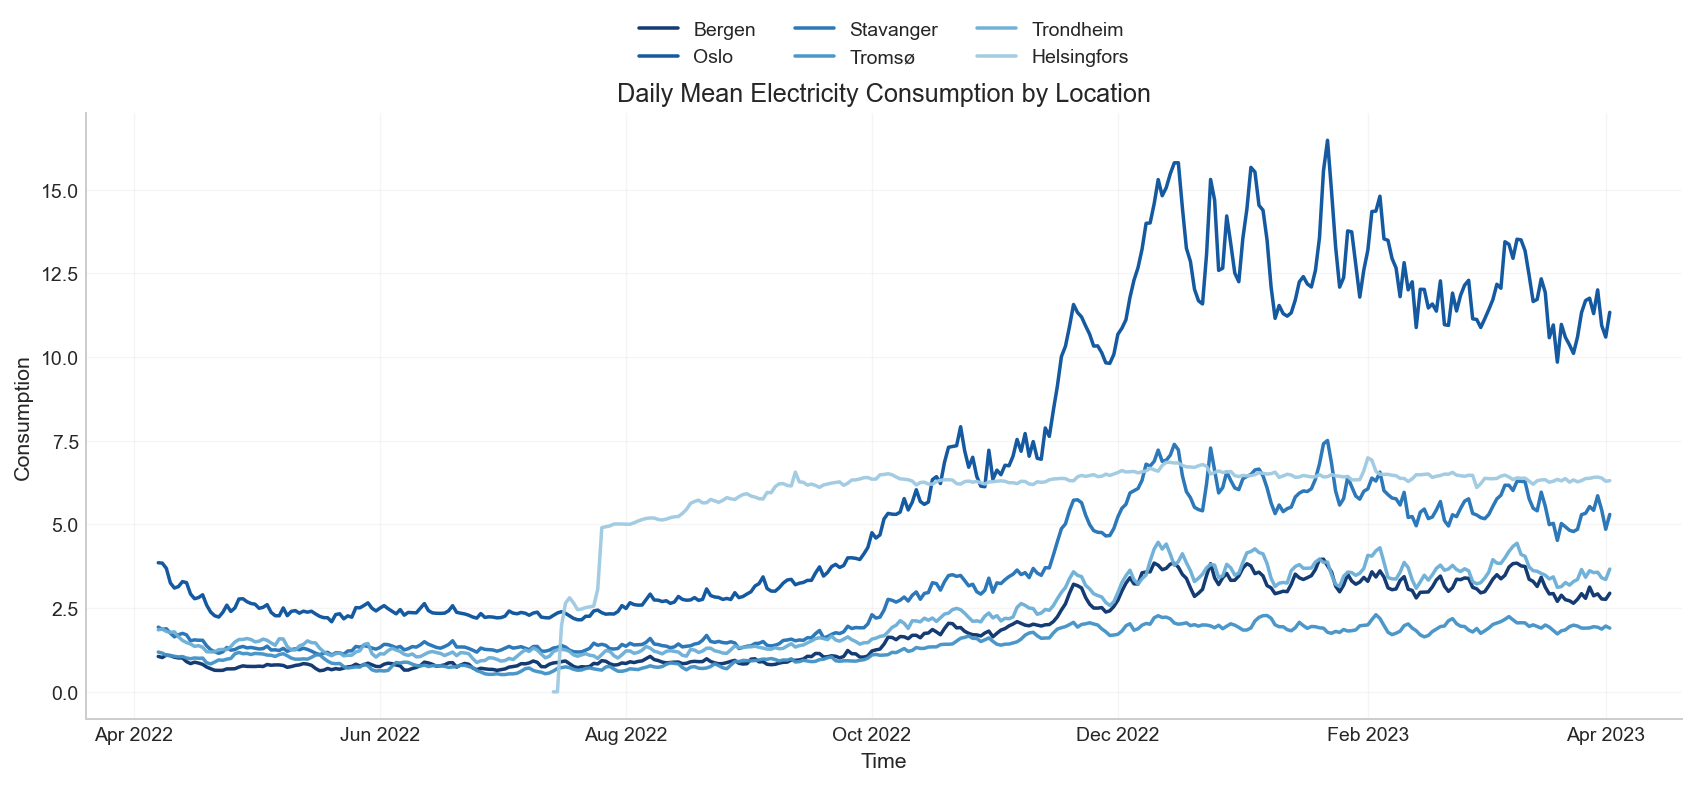

In [6]:
# Daily mean consumption for a cleaner overview figure
daily_consumption = (
    df_long
    .groupby(["location", pd.Grouper(key="time", freq="D")], as_index=False)["consumption"]
    .mean()
)

fig, ax = plt.subplots(figsize=(12, 5.5), constrained_layout=True)

for loc in location_dfs.keys():
    sub = daily_consumption[daily_consumption["location"] == loc]
    ax.plot(
        sub["time"],
        sub["consumption"],
        label=loc,
        color=location_colors[loc],
        linewidth=1.8,
        alpha=0.95
    )

ax.set_title("Daily Mean Electricity Consumption by Location")
ax.set_xlabel("Time")
ax.set_ylabel("Consumption")
ax.xaxis.set_major_locator(month_locator)
ax.xaxis.set_major_formatter(month_fmt)
ax.grid(True, alpha=0.25)
ax.legend(ncol=3, frameon=False, loc="upper center", bbox_to_anchor=(0.5, 1.18))

plt.show()

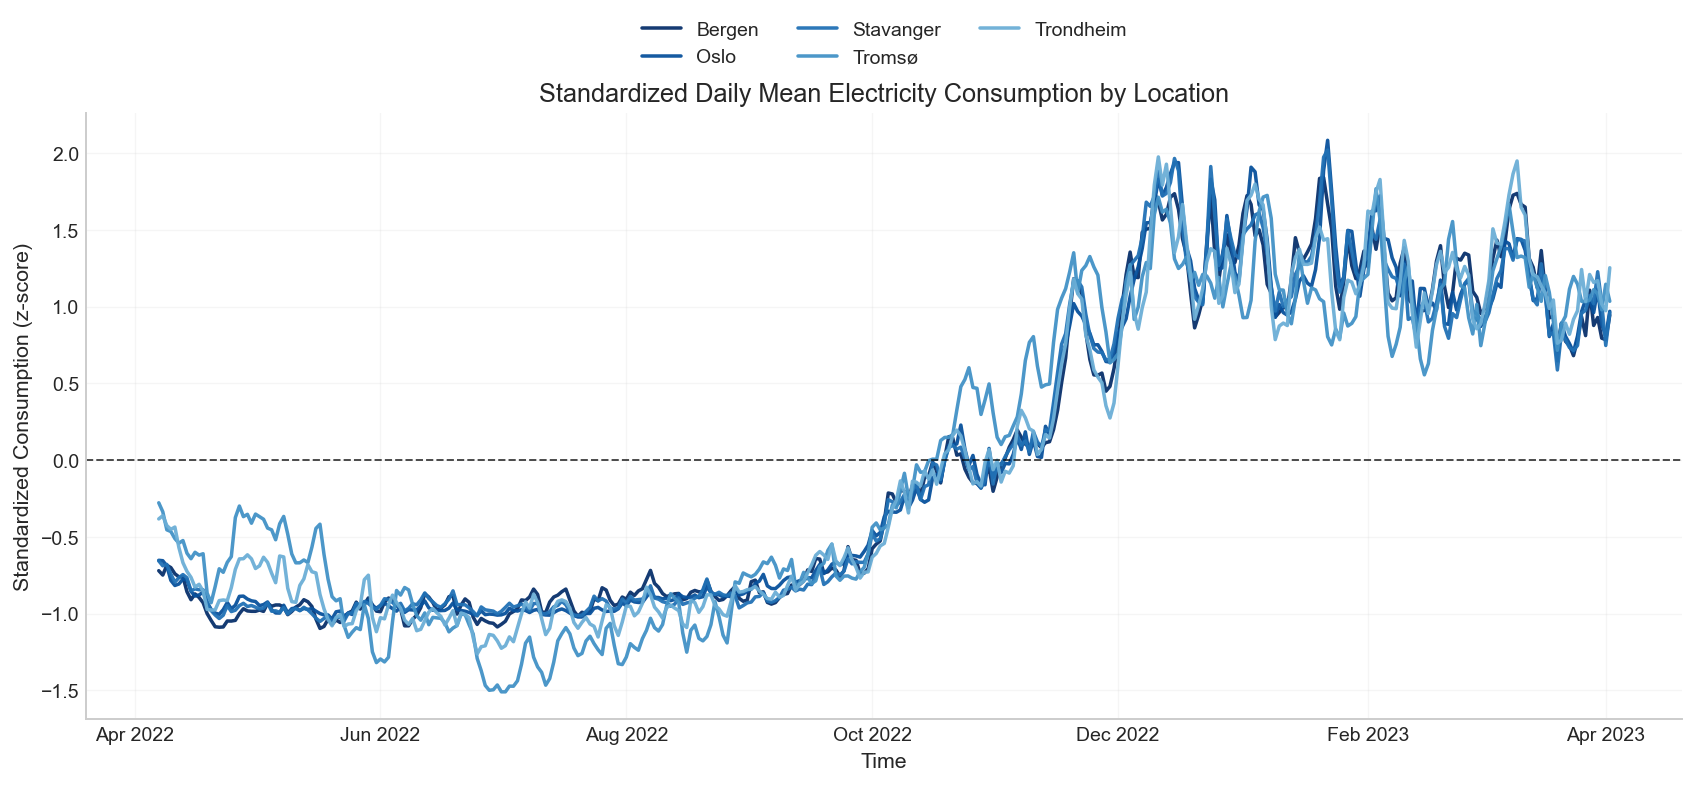

In [7]:
# Standardize daily mean consumption within each location
daily_std = daily_consumption.copy()
daily_std["consumption_z"] = (
    daily_std.groupby("location")["consumption"]
    .transform(lambda x: (x - x.mean()) / x.std())
)

# If you want to exclude Helsingfors to match the common five-location analysis:
locations_std = ["Bergen", "Oslo", "Stavanger", "Tromsø", "Trondheim"]

fig, ax = plt.subplots(figsize=(12, 5.5), constrained_layout=True)

for loc in locations_std:
    sub = daily_std[daily_std["location"] == loc]
    ax.plot(
        sub["time"],
        sub["consumption_z"],
        label=loc,
        color=location_colors[loc],
        linewidth=1.8,
        alpha=0.95
    )

ax.axhline(0, color="black", linewidth=1.0, linestyle="--", alpha=0.7)
ax.set_title("Standardized Daily Mean Electricity Consumption by Location")
ax.set_xlabel("Time")
ax.set_ylabel("Standardized Consumption (z-score)")
ax.xaxis.set_major_locator(month_locator)
ax.xaxis.set_major_formatter(month_fmt)
ax.grid(True, alpha=0.25)
ax.legend(ncol=3, frameon=False, loc="upper center", bbox_to_anchor=(0.5, 1.18))

plt.show()

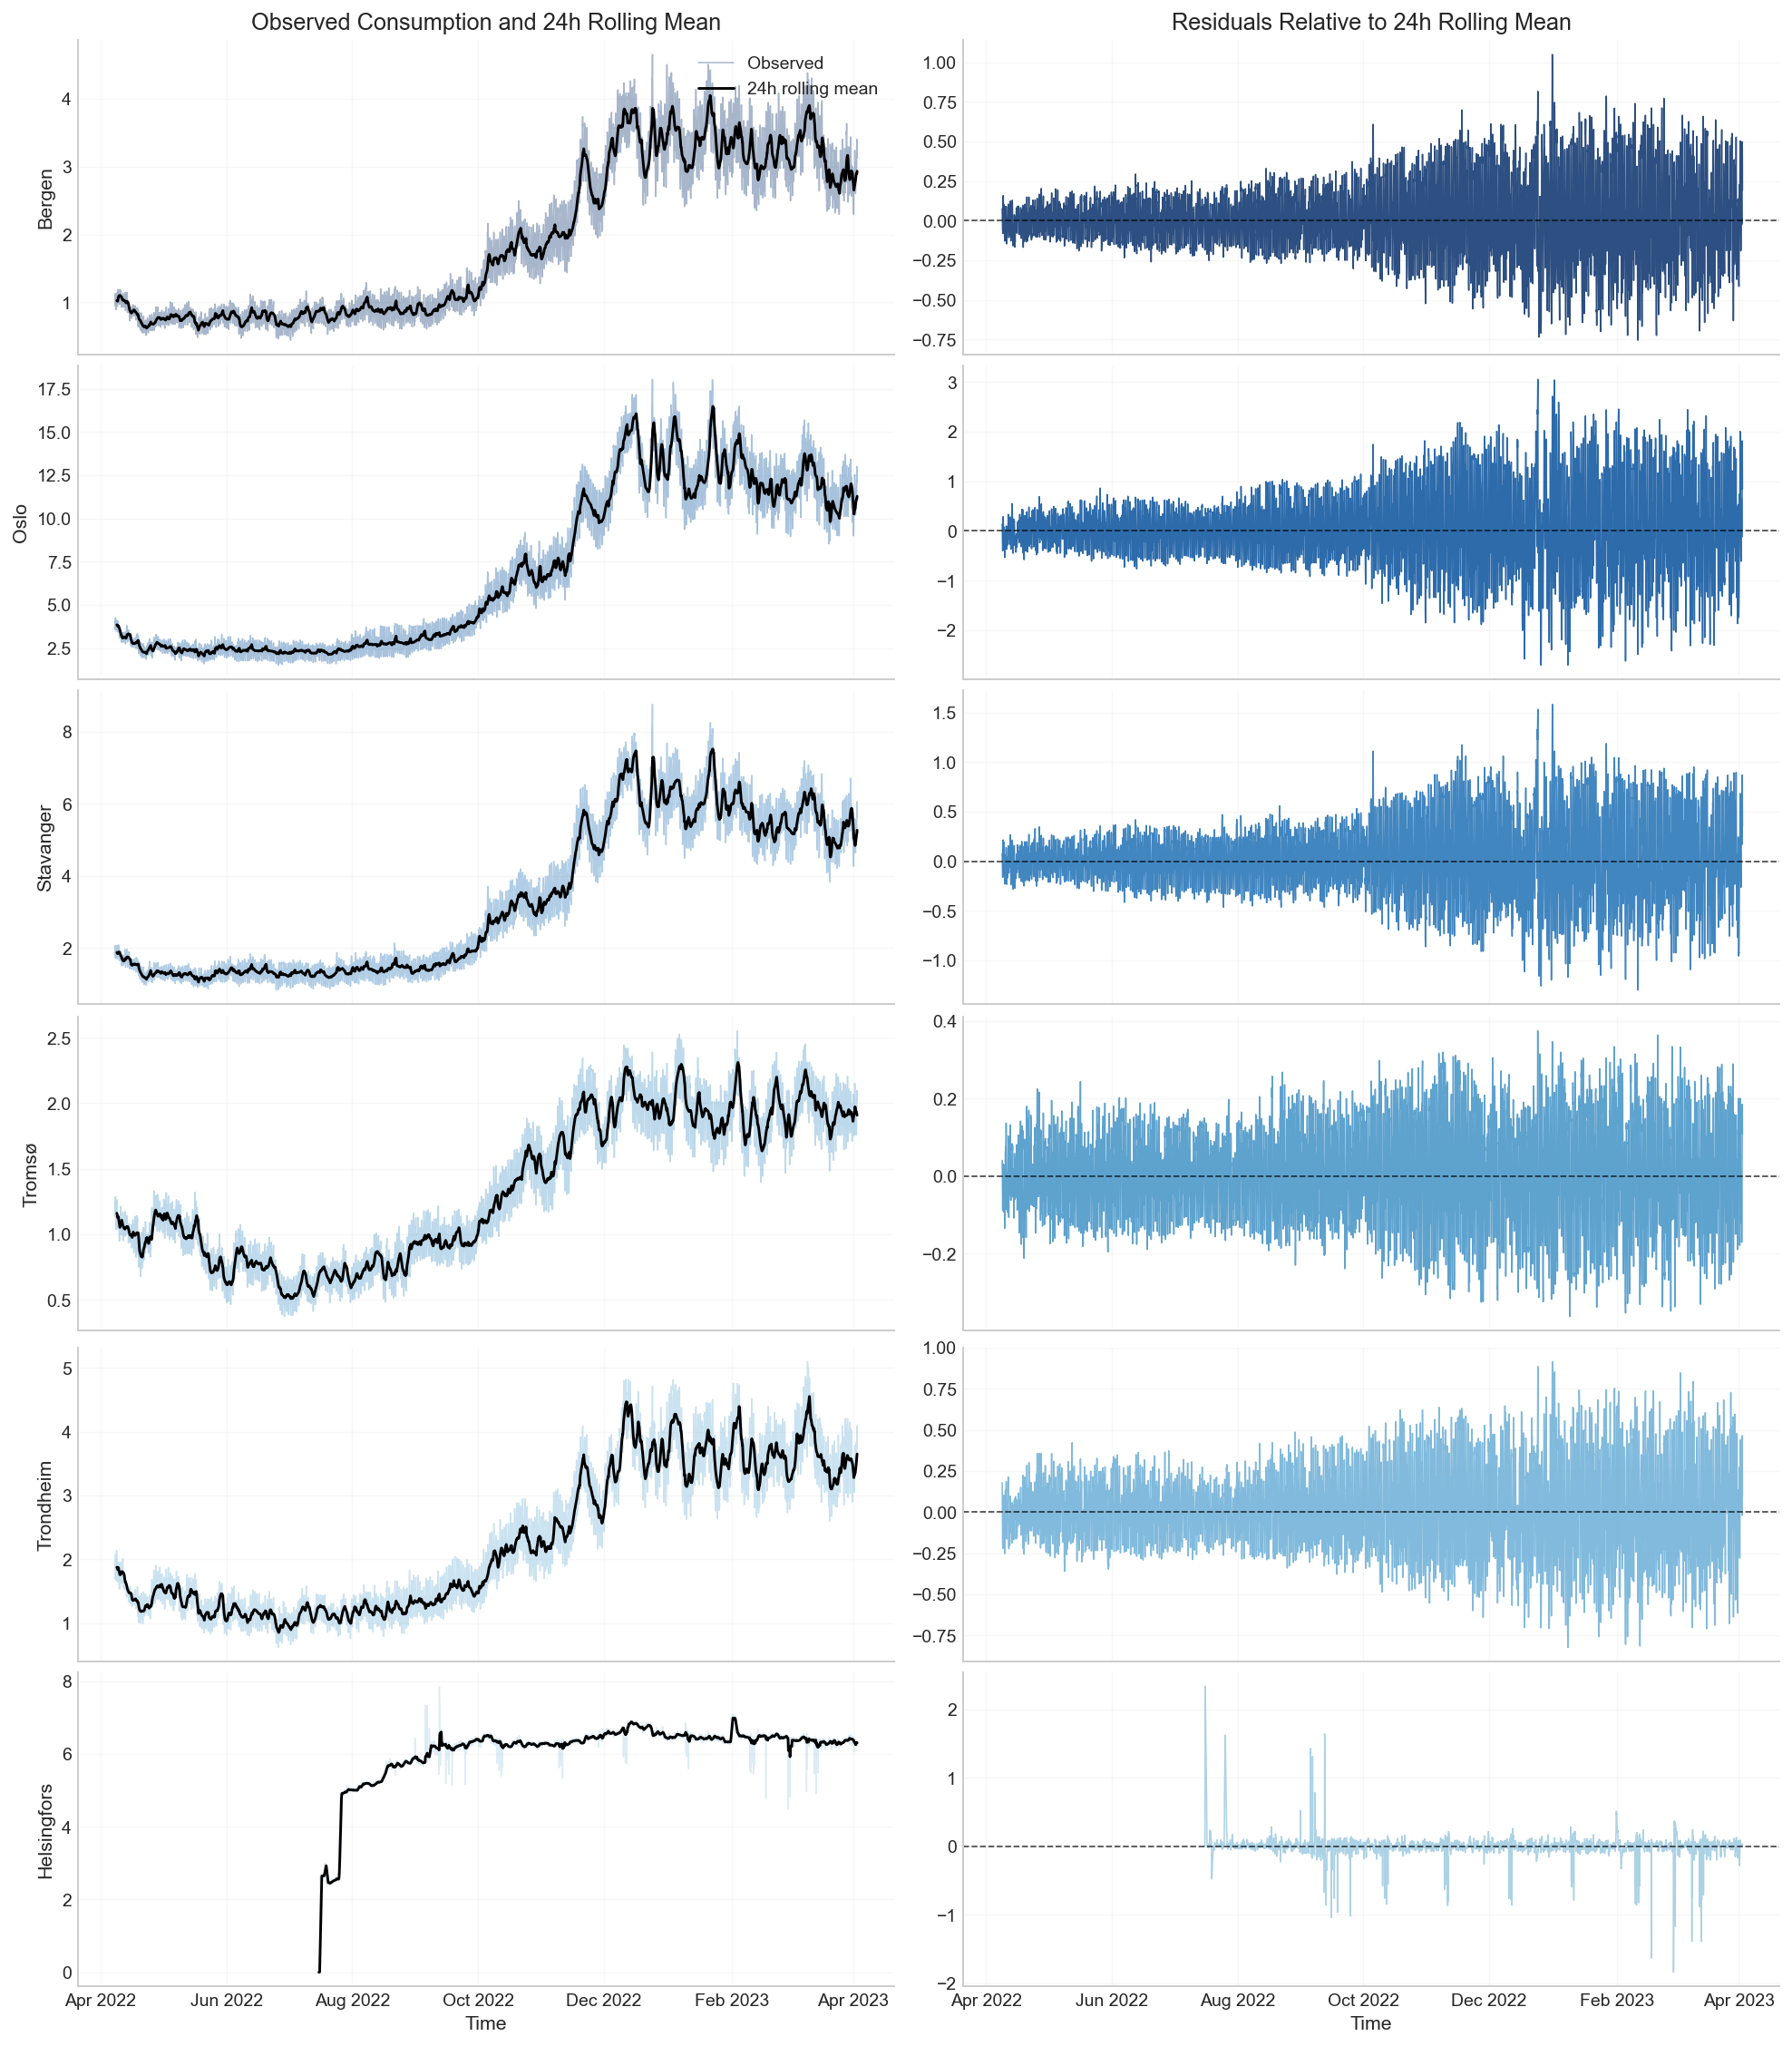

In [8]:
# Multi-panel figure: actual vs 24h rolling mean, plus residuals
locations = ["Bergen", "Oslo", "Stavanger", "Tromsø", "Trondheim", "Helsingfors"]

fig, axes = plt.subplots(
    nrows=len(locations),
    ncols=2,
    figsize=(14, 16),
    sharex=True,
    constrained_layout=True
)

for i, loc in enumerate(locations):
    d = location_dfs[loc].copy().sort_values("time")
    d["rolling_mean_24h"] = d["consumption"].rolling(window=24, min_periods=24).mean()
    d["residual_24h"] = d["consumption"] - d["rolling_mean_24h"]

    ax_left = axes[i, 0]
    ax_right = axes[i, 1]

    # Actual + rolling mean
    ax_left.plot(
        d["time"],
        d["consumption"],
        color=location_colors[loc],
        linewidth=0.8,
        alpha=0.35,
        label="Observed"
    )
    ax_left.plot(
        d["time"],
        d["rolling_mean_24h"],
        color="black",
        linewidth=1.5,
        label="24h rolling mean"
    )
    ax_left.set_ylabel(loc)
    ax_left.grid(True, alpha=0.2)

    # Residuals
    ax_right.plot(
        d["time"],
        d["residual_24h"],
        color=location_colors[loc],
        linewidth=0.8,
        alpha=0.85
    )
    ax_right.axhline(0, color="black", linestyle="--", linewidth=0.9, alpha=0.7)
    ax_right.grid(True, alpha=0.2)

# Column titles
axes[0, 0].set_title("Observed Consumption and 24h Rolling Mean")
axes[0, 1].set_title("Residuals Relative to 24h Rolling Mean")

# X-axis formatting on bottom row
for ax in axes[-1, :]:
    ax.xaxis.set_major_locator(month_locator)
    ax.xaxis.set_major_formatter(month_fmt)
    ax.set_xlabel("Time")

# Add one legend only
axes[0, 0].legend(frameon=False, loc="upper right")

plt.show()

In [9]:
# --- Load predictions ---
predictions = pd.read_csv("predictions.csv")
predictions["timestamp"] = pd.to_datetime(predictions["timestamp"])

baseline = pd.read_csv("baseline_avg_120_168_predictions.csv")
baseline["timestamp"] = pd.to_datetime(baseline["timestamp"])

# Raw data for historical context
raw = df.copy()
raw["time"] = pd.to_datetime(raw["time"])

locations = sorted(predictions["location"].unique())
test_start = predictions["timestamp"].min()
test_end = predictions["timestamp"].max()

print(f"Test window: {test_start.date()} → {test_end.date()}")
print(f"Locations: {locations}")
print(f"Prediction rows: {len(predictions)}, Baseline rows: {len(baseline)}")

Test window: 2023-03-20 → 2023-04-02
Locations: ['bergen', 'oslo', 'stavanger', 'tromsø', 'trondheim']
Prediction rows: 1670, Baseline rows: 1670


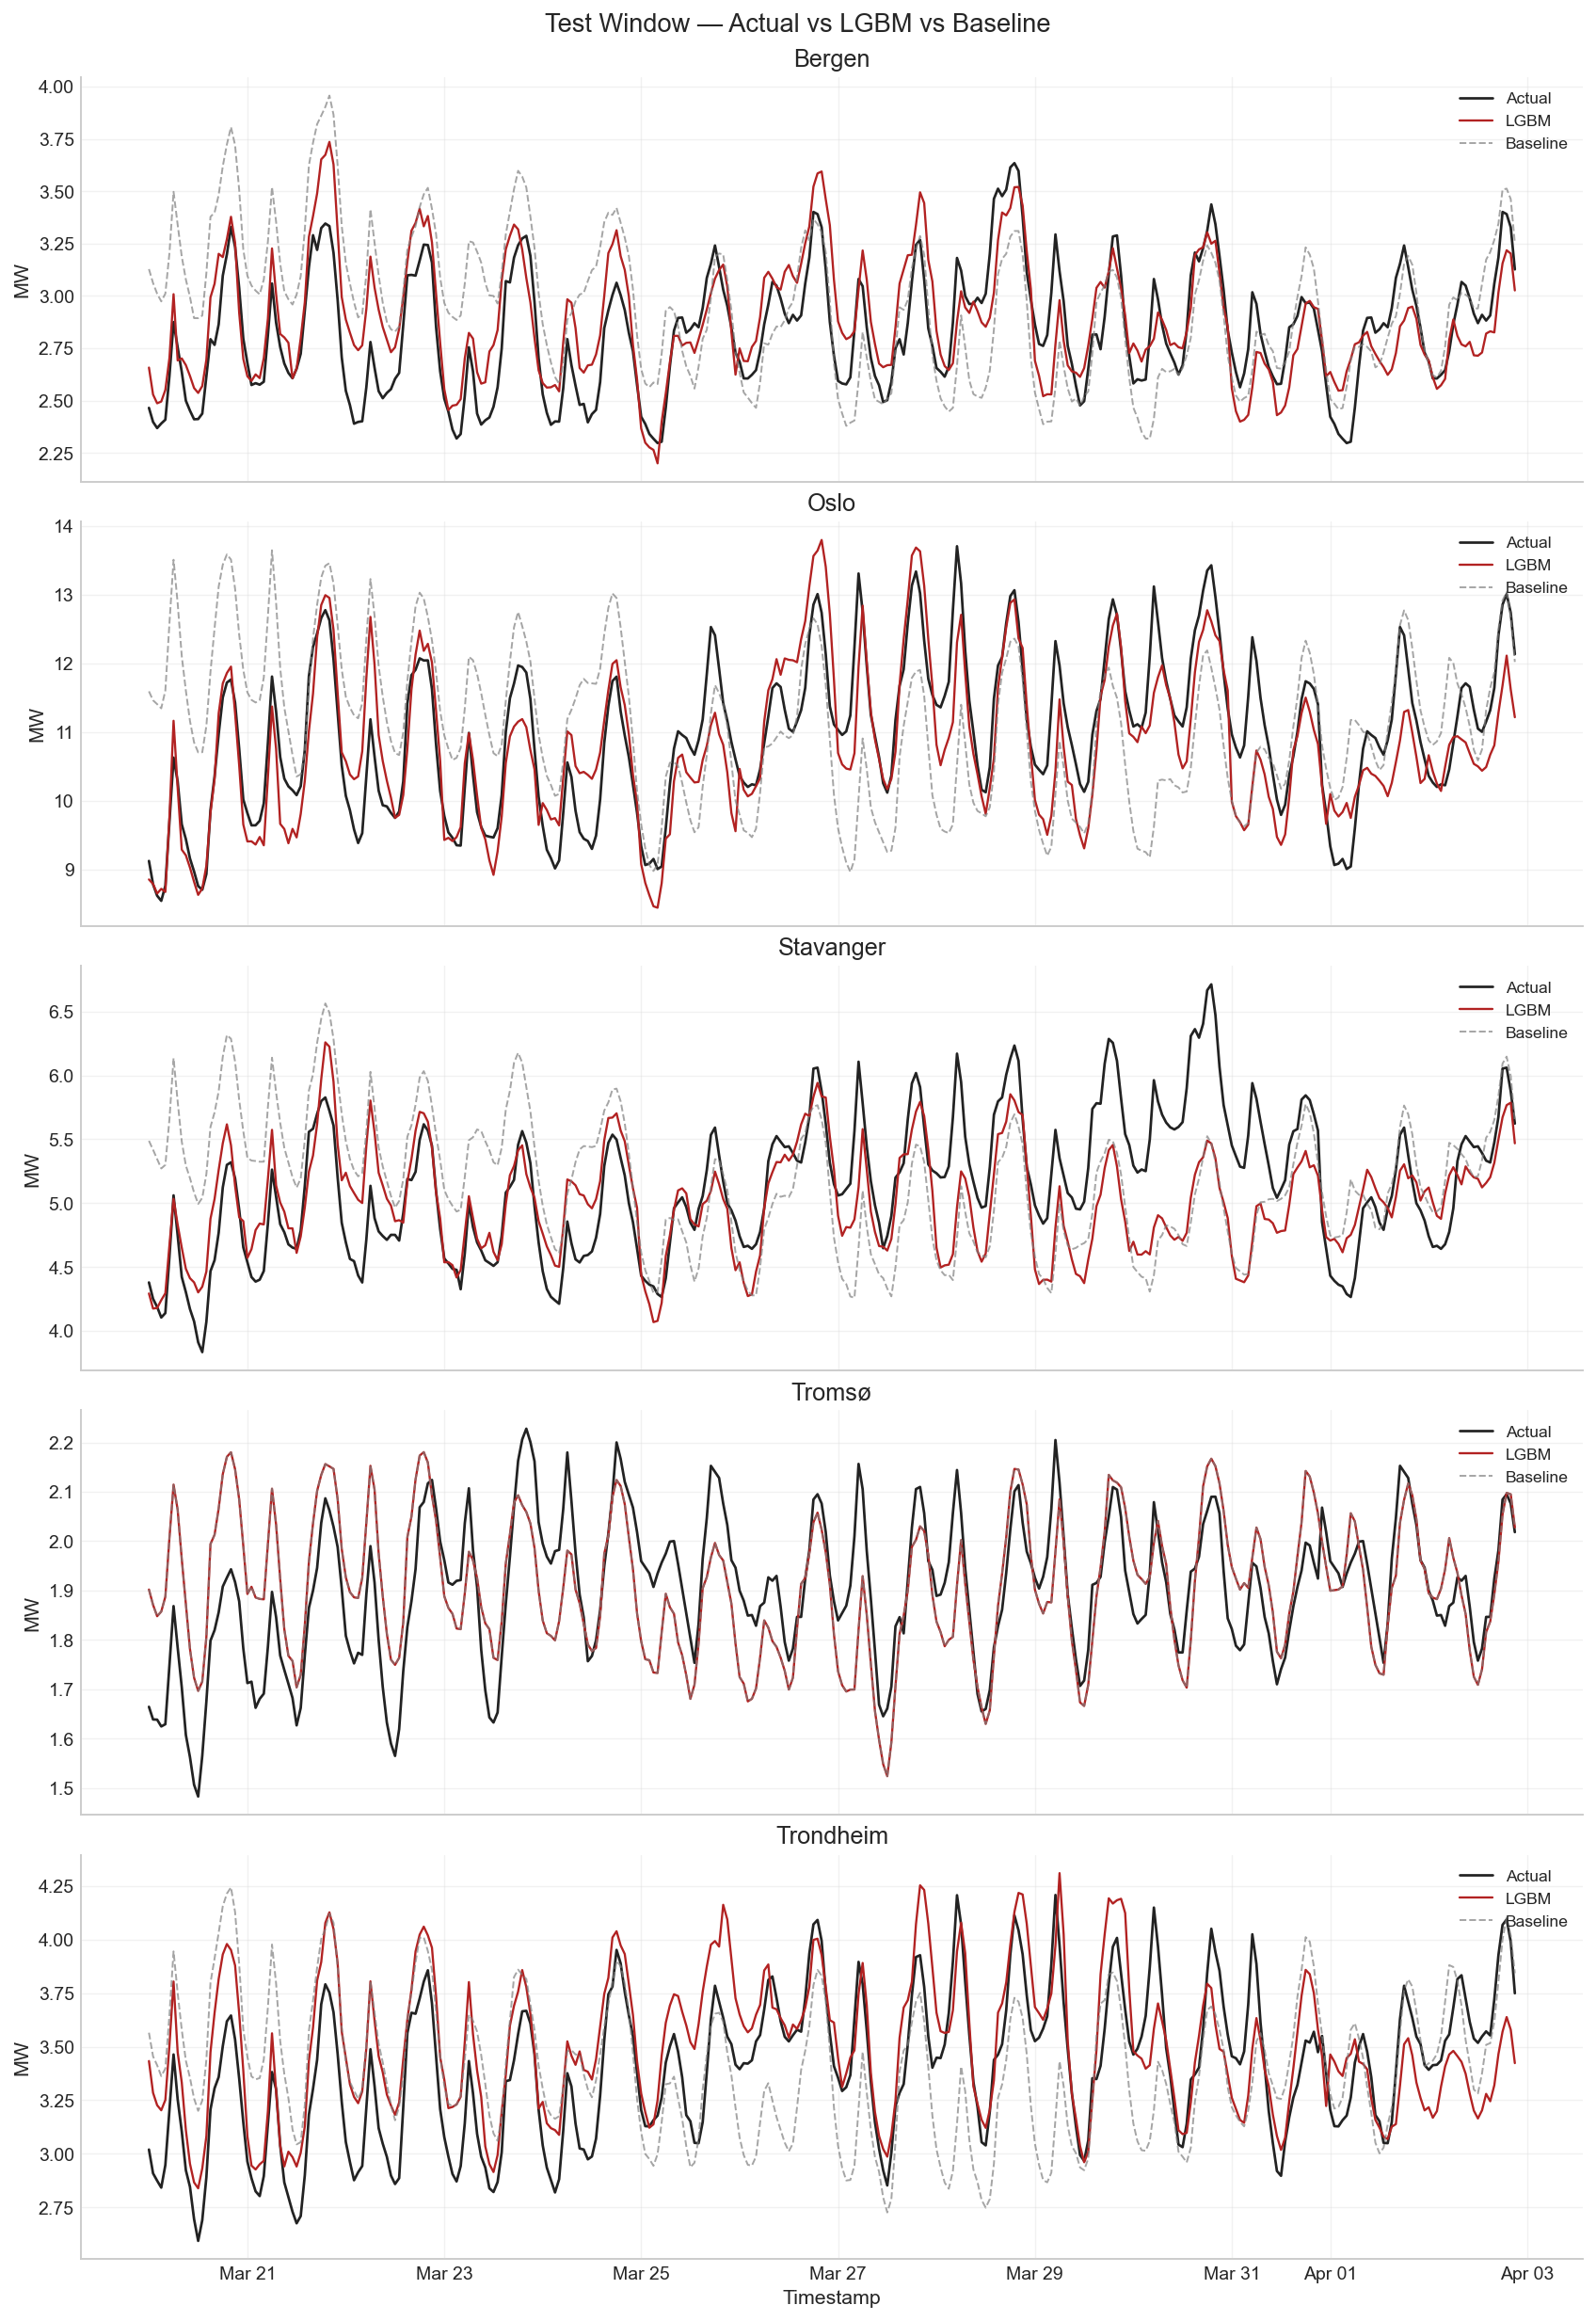

In [10]:
fig, axes = plt.subplots(len(locations), 1, figsize=(12, 3.5 * len(locations)),
                         sharex=True, constrained_layout=True)

for ax, loc in zip(axes, locations):
    lp = predictions[predictions["location"] == loc].sort_values("timestamp")
    lb = baseline[baseline["location"] == loc].sort_values("timestamp")

    ax.plot(lp["timestamp"], lp["y_true_mw"], color="#222222", label="Actual", linewidth=1.4)
    ax.plot(lp["timestamp"], lp["y_pred_mw"], color="#b22222", label="LGBM", linewidth=1.2)
    ax.plot(lb["timestamp"], lb["y_pred"], color="#7f7f7f",
            label="Baseline", linestyle="--", linewidth=1, alpha=0.7)

    ax.set_ylabel("MW")
    ax.set_title(loc.capitalize())
    ax.legend(loc="upper right", fontsize=9)

axes[-1].set_xlabel("Timestamp")
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.suptitle("Test Window — Actual vs LGBM vs Baseline", fontsize=14)
plt.savefig("test_window_per_location.png", bbox_inches="tight")
plt.show()

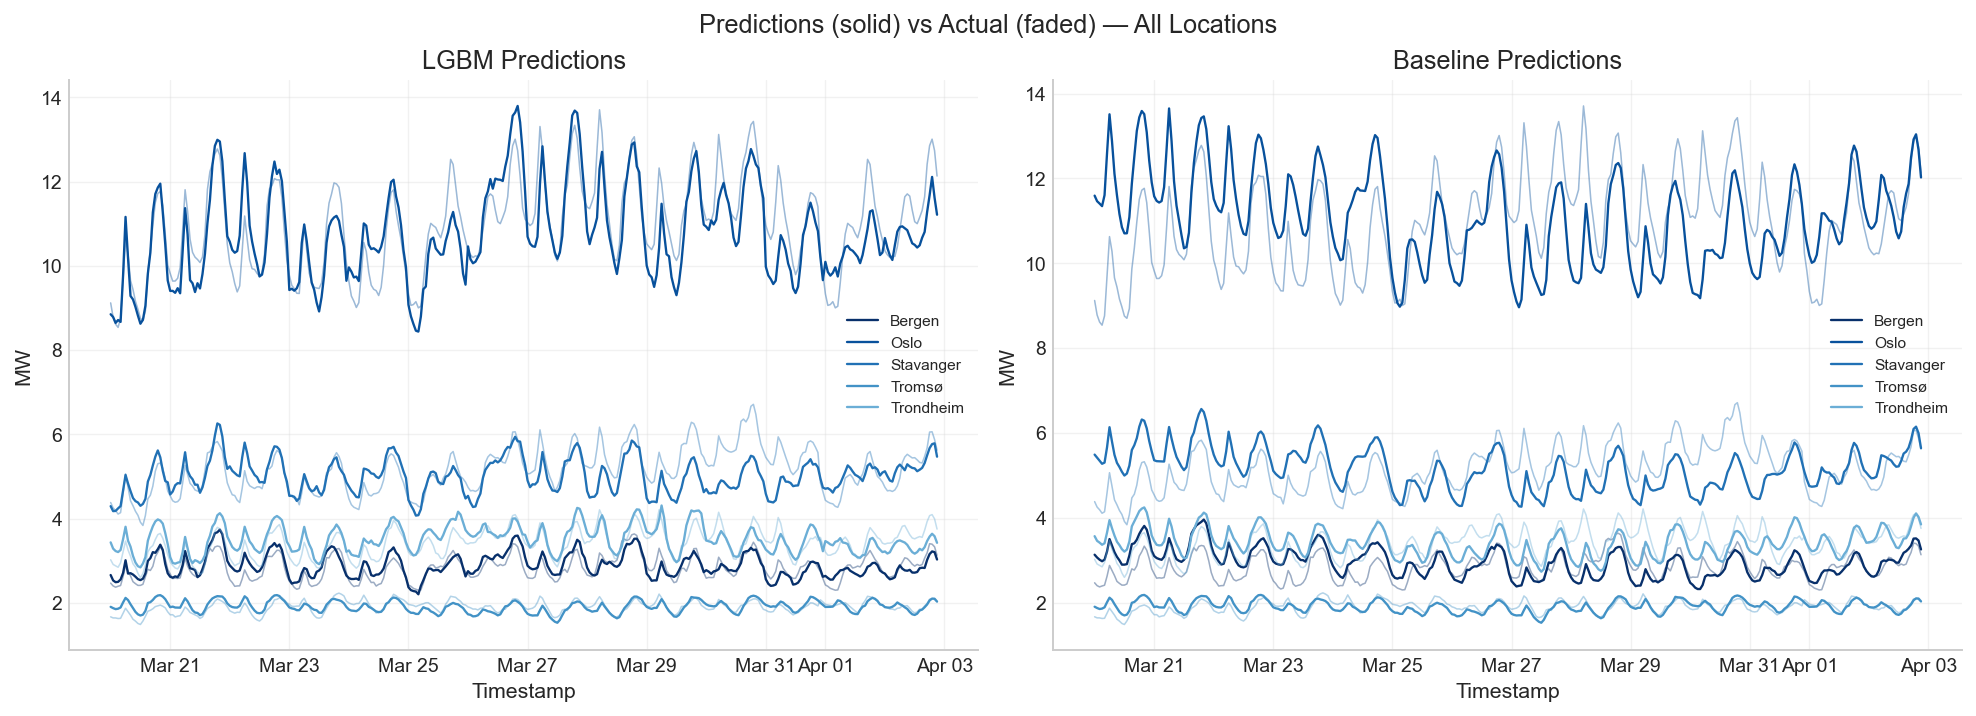

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

loc_colors_nor = {
    "bergen": "#08306b", "oslo": "#08519c", "stavanger": "#2171b5",
    "tromsø": "#4292c6", "trondheim": "#6baed6",
}

for ax, (label, col_true, col_pred, df_src) in zip(axes, [
    ("LGBM Predictions", "y_true_mw", "y_pred_mw", predictions),
    ("Baseline Predictions", "y_true", "y_pred", baseline),
]):
    for loc in locations:
        ld = df_src[df_src["location"] == loc].sort_values("timestamp")
        ax.plot(ld["timestamp"], ld[col_true], color=loc_colors_nor[loc],
                linewidth=0.8, alpha=0.4)
        ax.plot(ld["timestamp"], ld[col_pred], color=loc_colors_nor[loc],
                linewidth=1.2, label=loc.capitalize())
    ax.set(title=label, xlabel="Timestamp", ylabel="MW")
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

plt.suptitle("Predictions (solid) vs Actual (faded) — All Locations", fontsize=13)
plt.savefig("test_window_overlaid.png", bbox_inches="tight")
plt.show()

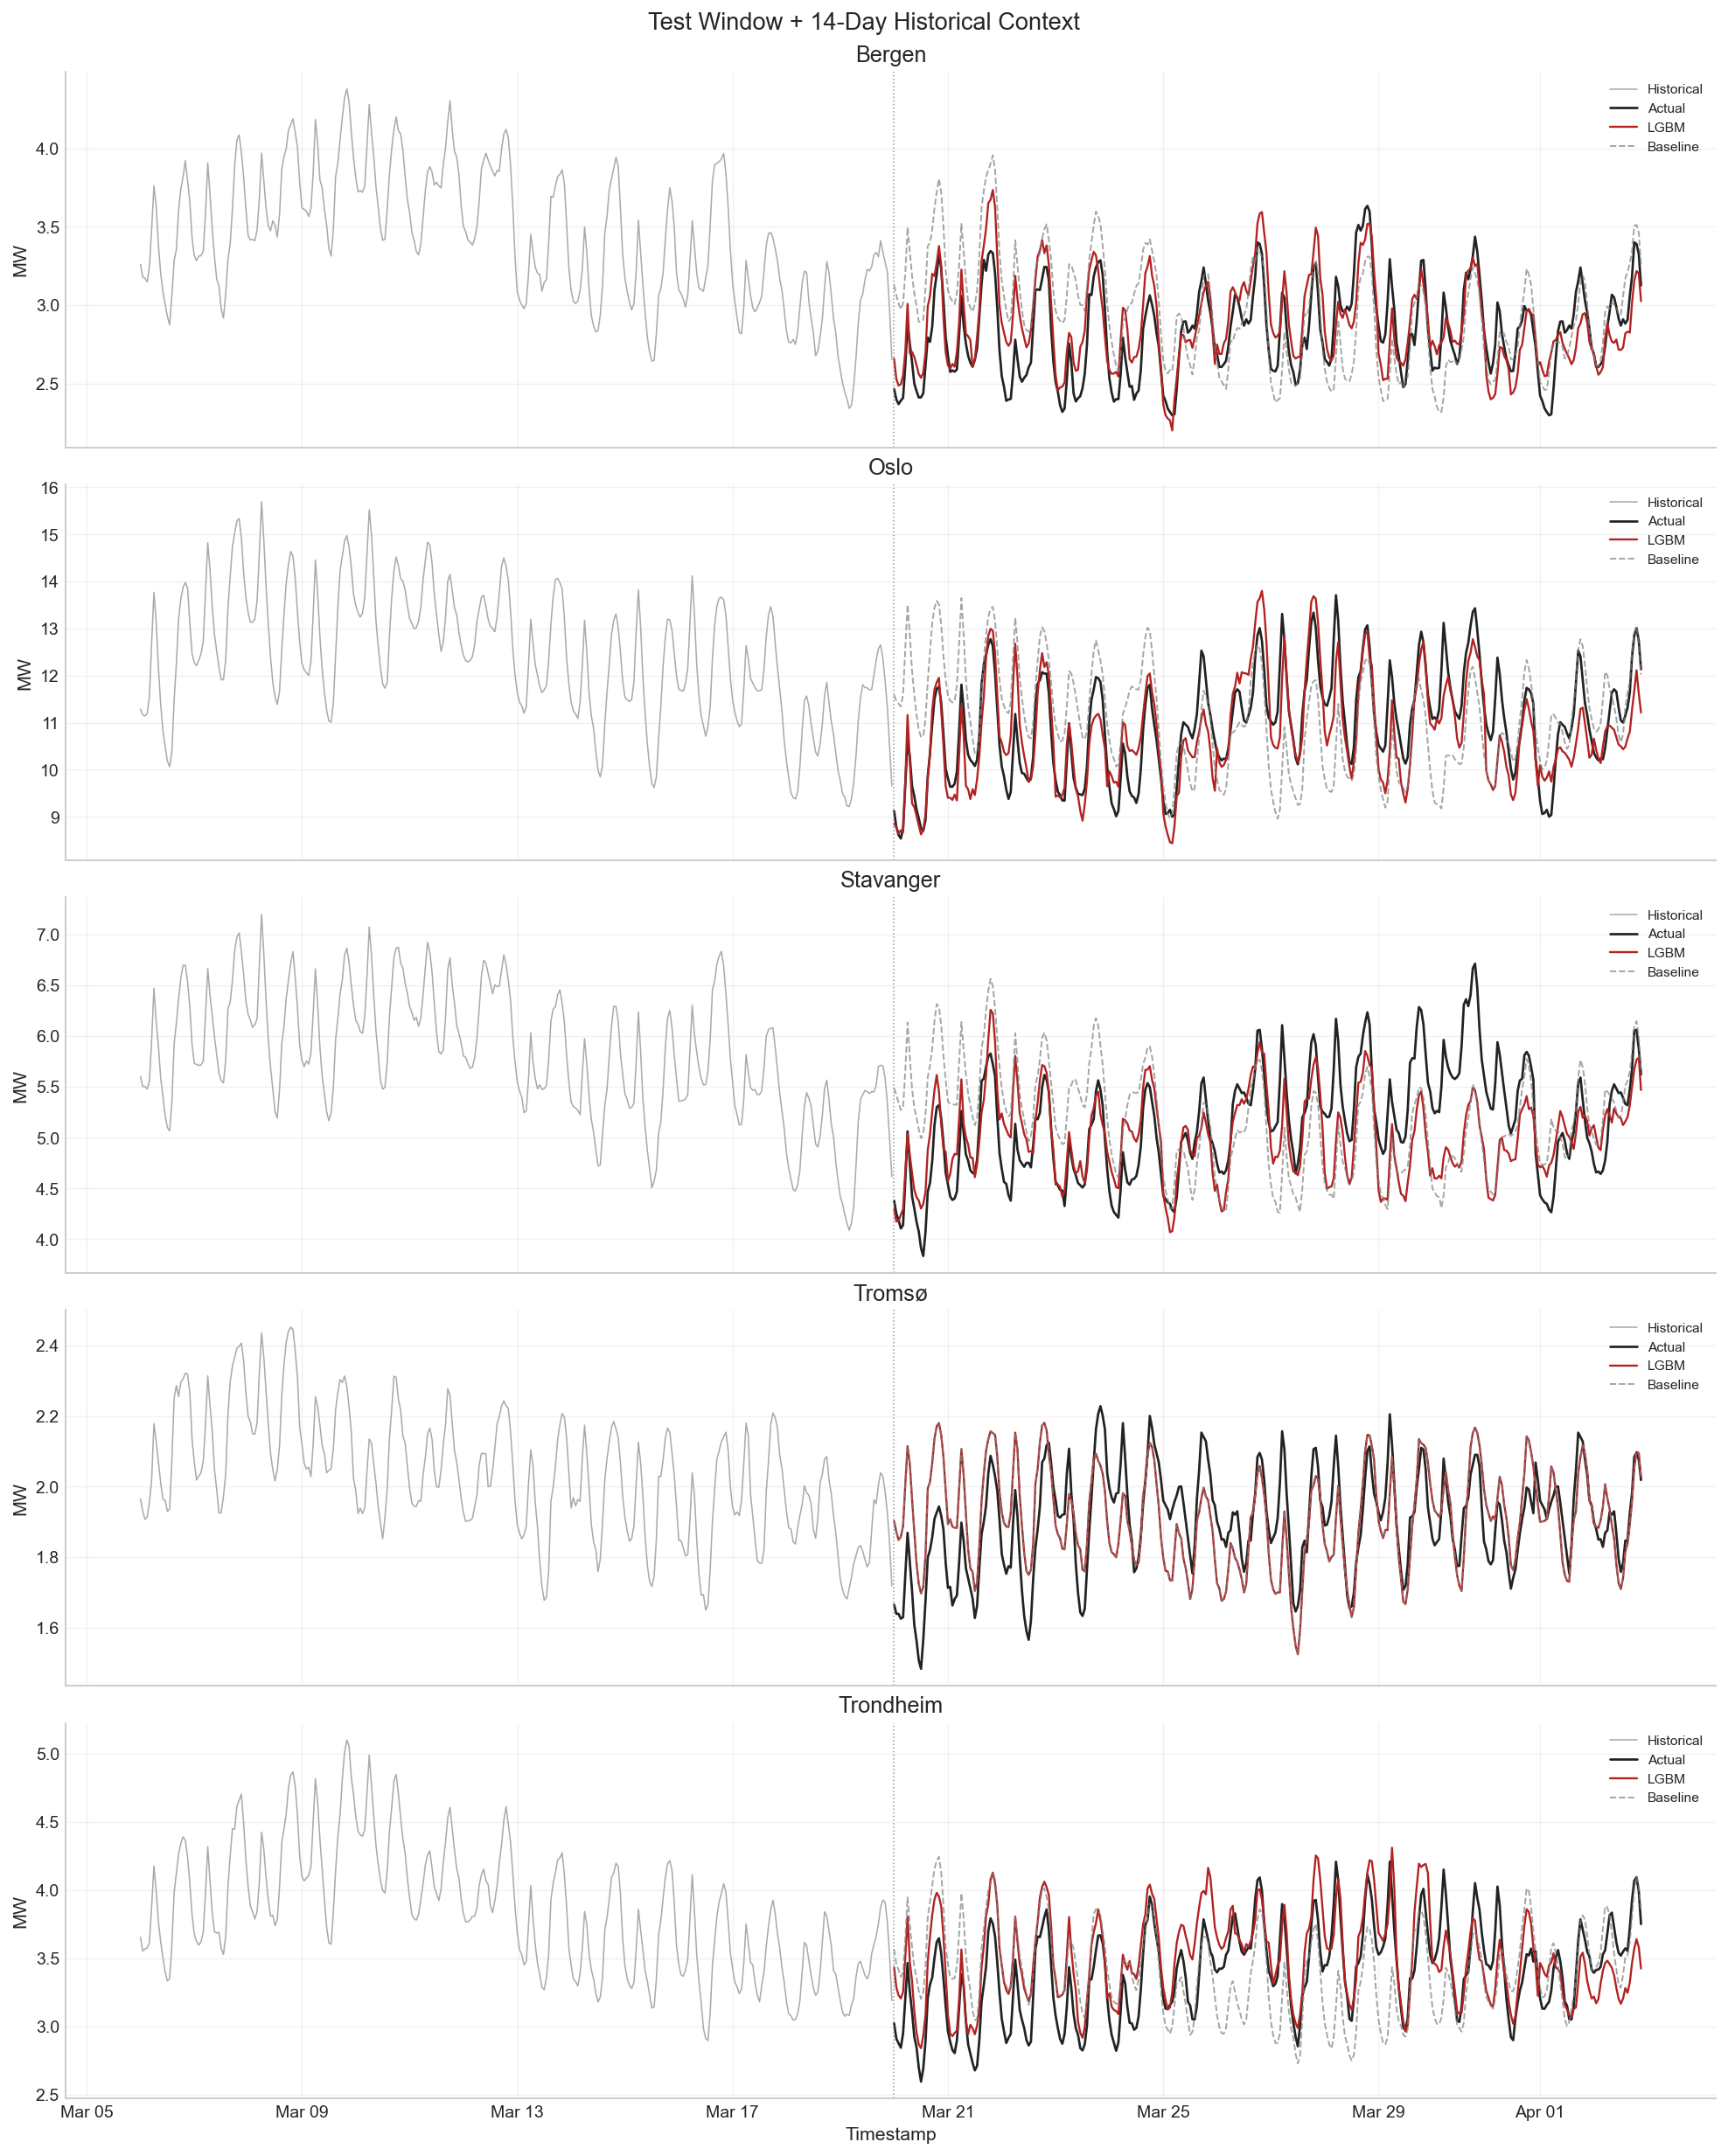

In [12]:
context_days = 14
context_start = test_start - pd.Timedelta(days=context_days)

fig, axes = plt.subplots(len(locations), 1, figsize=(14, 3.5 * len(locations)),
                         sharex=True, constrained_layout=True)

for ax, loc in zip(axes, locations):
    # Historical data
    hist = raw[(raw["location"] == loc) & (raw["time"] >= context_start) & (raw["time"] < test_start)]
    ax.plot(hist["time"], hist["consumption"], color="#AAAAAA", linewidth=0.8, label="Historical")

    # Test window
    lp = predictions[predictions["location"] == loc].sort_values("timestamp")
    lb = baseline[baseline["location"] == loc].sort_values("timestamp")

    ax.plot(lp["timestamp"], lp["y_true_mw"], color="#222222", label="Actual", linewidth=1.4)
    ax.plot(lp["timestamp"], lp["y_pred_mw"], color="#b22222", label="LGBM", linewidth=1.2)
    ax.plot(lb["timestamp"], lb["y_pred"], color="#7f7f7f",
            label="Baseline", linestyle="--", linewidth=1, alpha=0.7)

    # Mark test window boundary
    ax.axvline(test_start, color="#999999", linestyle=":", linewidth=0.8)

    ax.set_ylabel("MW")
    ax.set_title(loc.capitalize())
    ax.legend(loc="upper right", fontsize=8)

axes[-1].set_xlabel("Timestamp")
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.suptitle("Test Window + 14-Day Historical Context", fontsize=14)
plt.savefig("test_window_with_context.png", bbox_inches="tight")
plt.show()

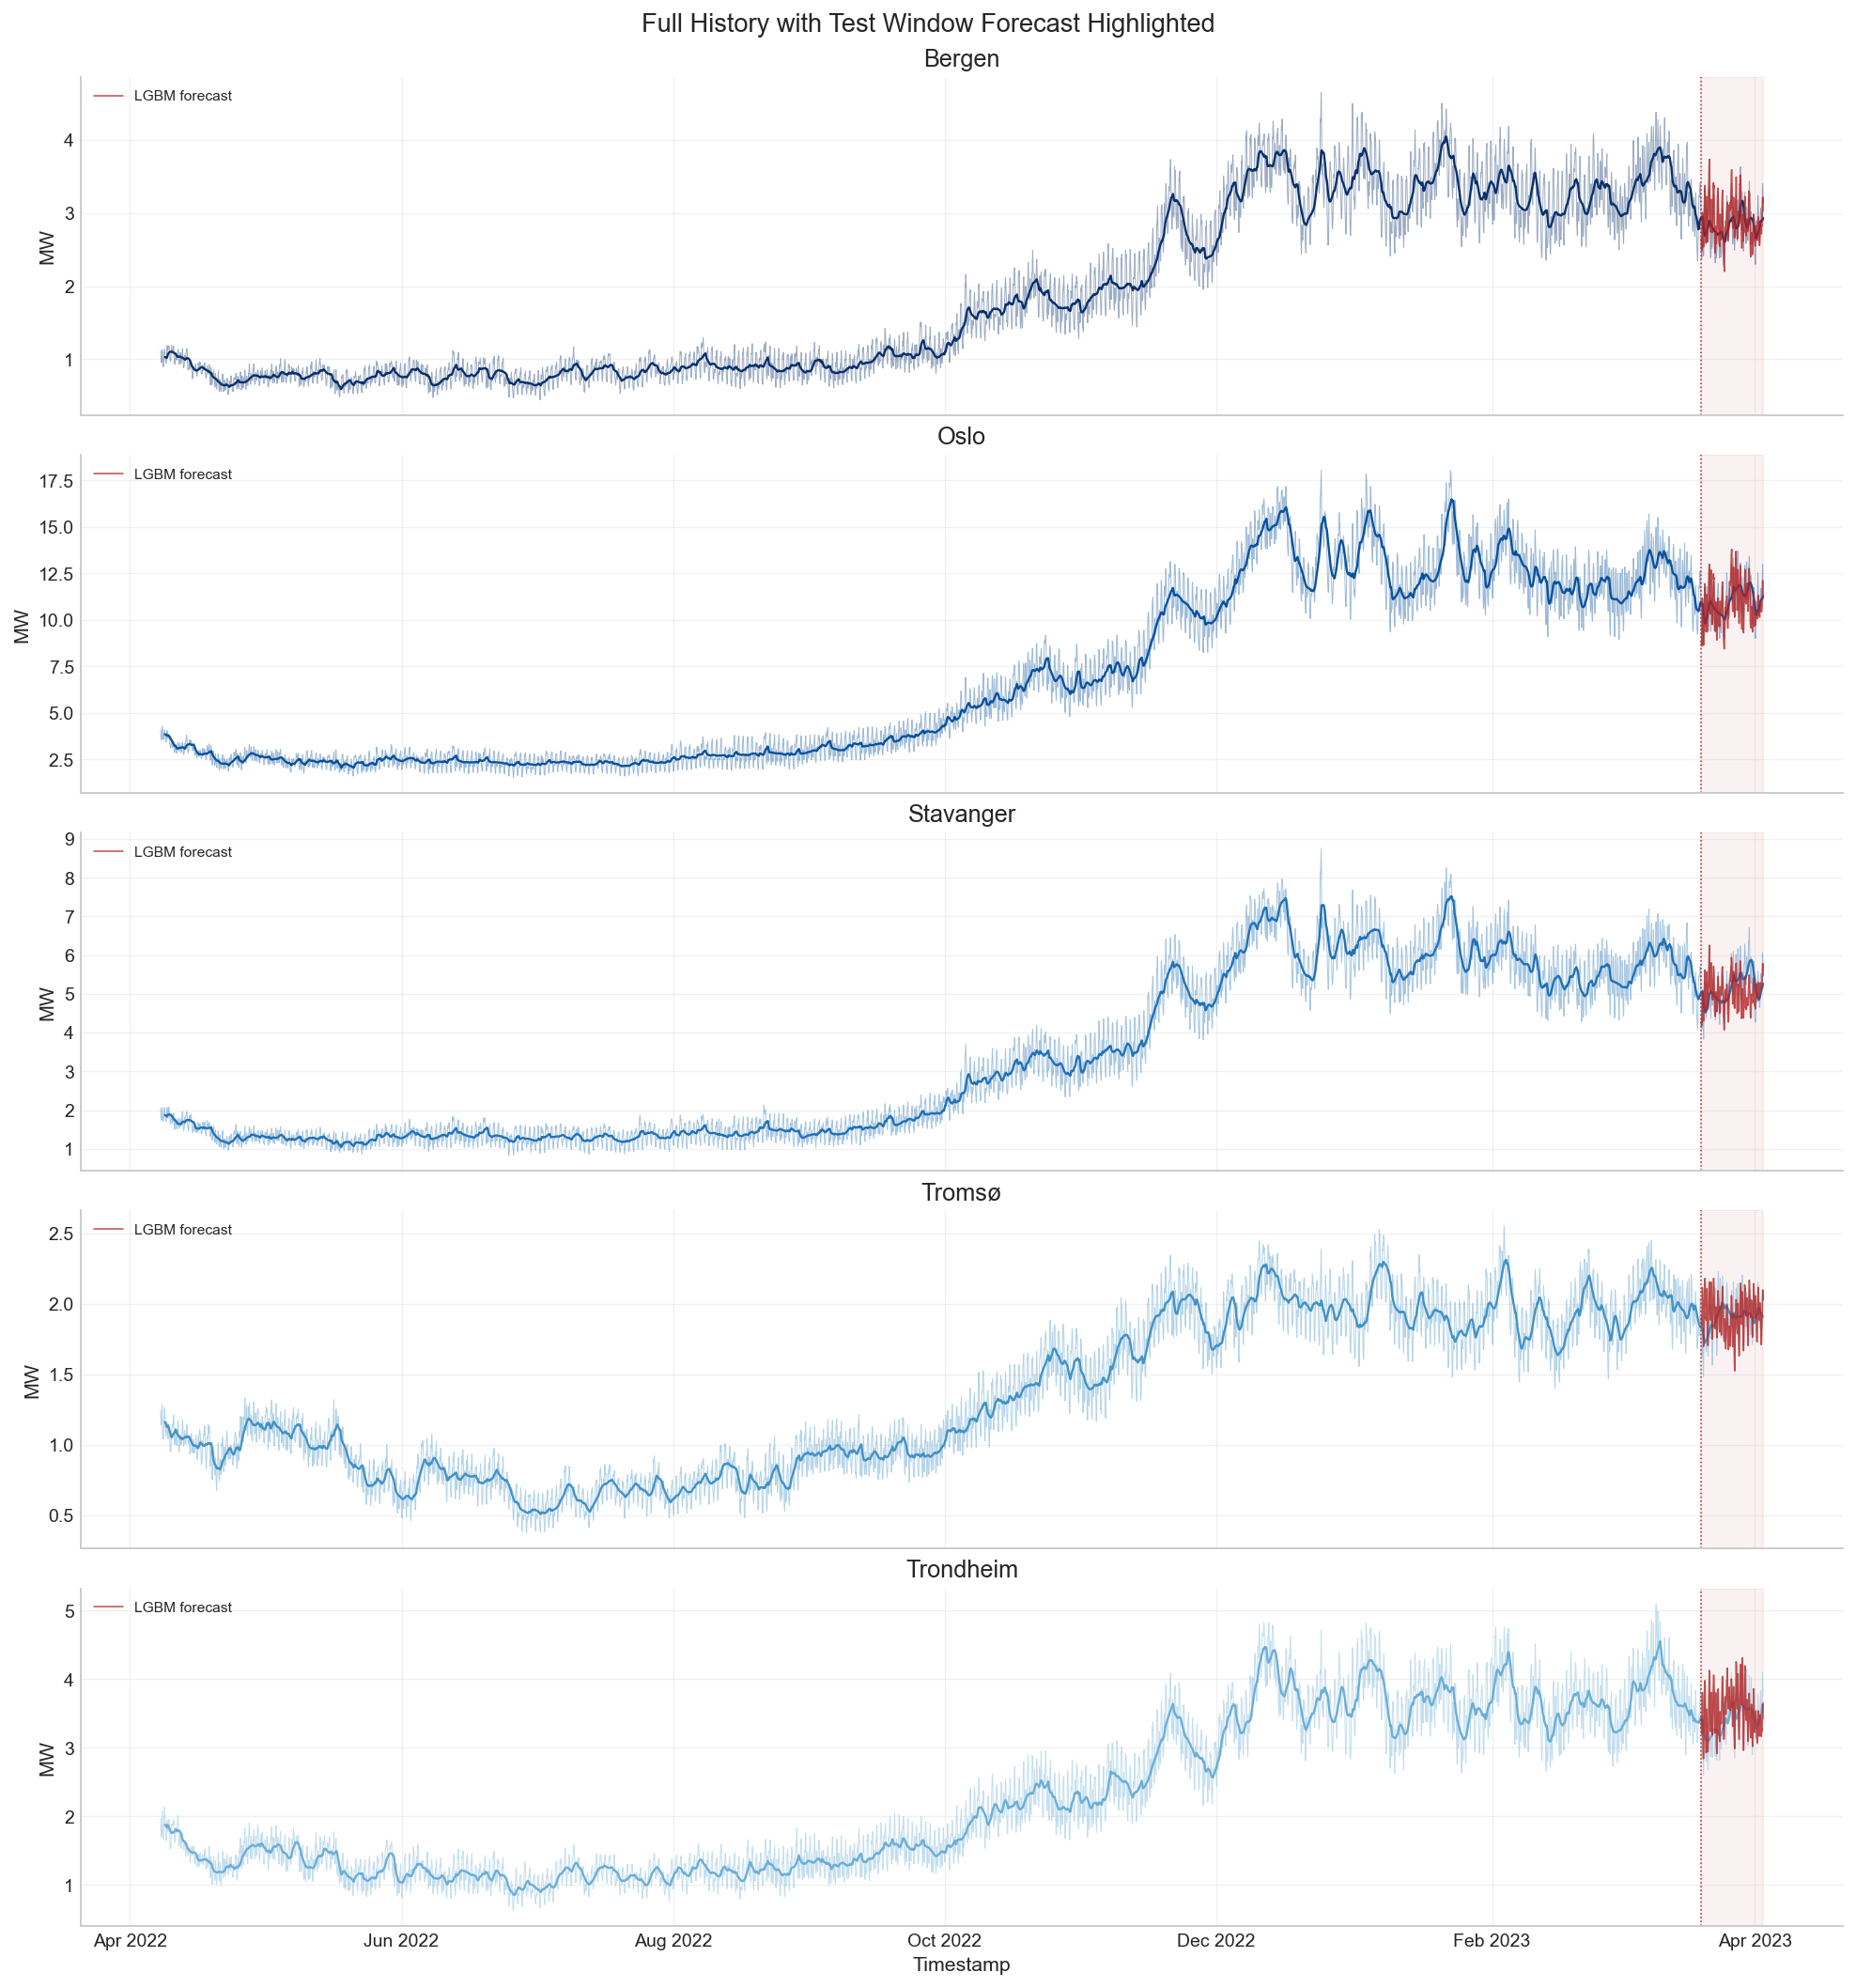

In [13]:
fig, axes = plt.subplots(len(locations), 1, figsize=(14, 3 * len(locations)),
                         sharex=True, constrained_layout=True)

for ax, loc in zip(axes, locations):
    # Full historical data
    hist = raw[raw["location"] == loc].sort_values("time")
    ax.plot(hist["time"], hist["consumption"], color=loc_colors_nor[loc],
            linewidth=0.5, alpha=0.4)

    # Daily rolling mean for readability
    daily = hist.set_index("time")["consumption"].rolling(24).mean()
    ax.plot(daily.index, daily.values, color=loc_colors_nor[loc], linewidth=1.2)

    # Test window predictions
    lp = predictions[predictions["location"] == loc].sort_values("timestamp")
    ax.plot(lp["timestamp"], lp["y_pred_mw"], color="#b22222", linewidth=0.8, label="LGBM forecast", alpha=0.8)

    # Mark test window
    ax.axvspan(test_start, test_end, color="#b22222", alpha=0.06)
    ax.axvline(test_start, color="#b22222", linestyle=":", linewidth=0.8)

    ax.set_ylabel("MW")
    ax.set_title(loc.capitalize())
    ax.legend(loc="upper left", fontsize=8)

axes[-1].set_xlabel("Timestamp")
axes[-1].xaxis.set_major_locator(month_locator)
axes[-1].xaxis.set_major_formatter(month_fmt)
plt.suptitle("Full History with Test Window Forecast Highlighted", fontsize=14)
plt.savefig("full_history_with_forecast.png", bbox_inches="tight")
plt.show()

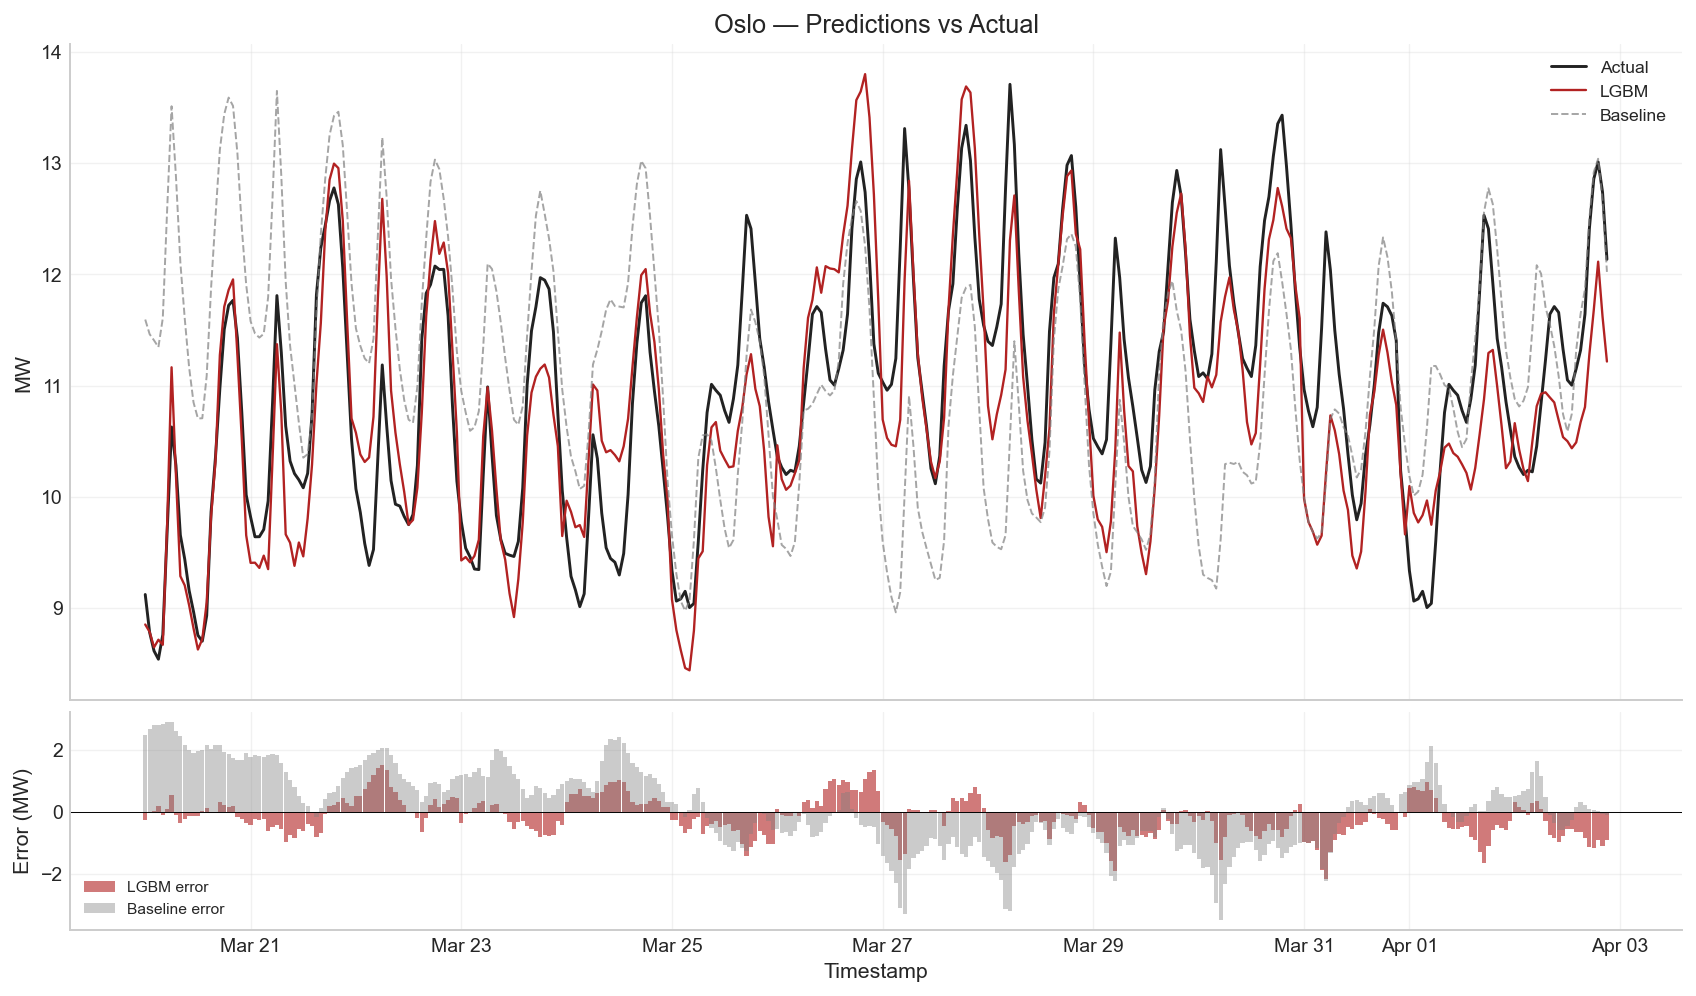

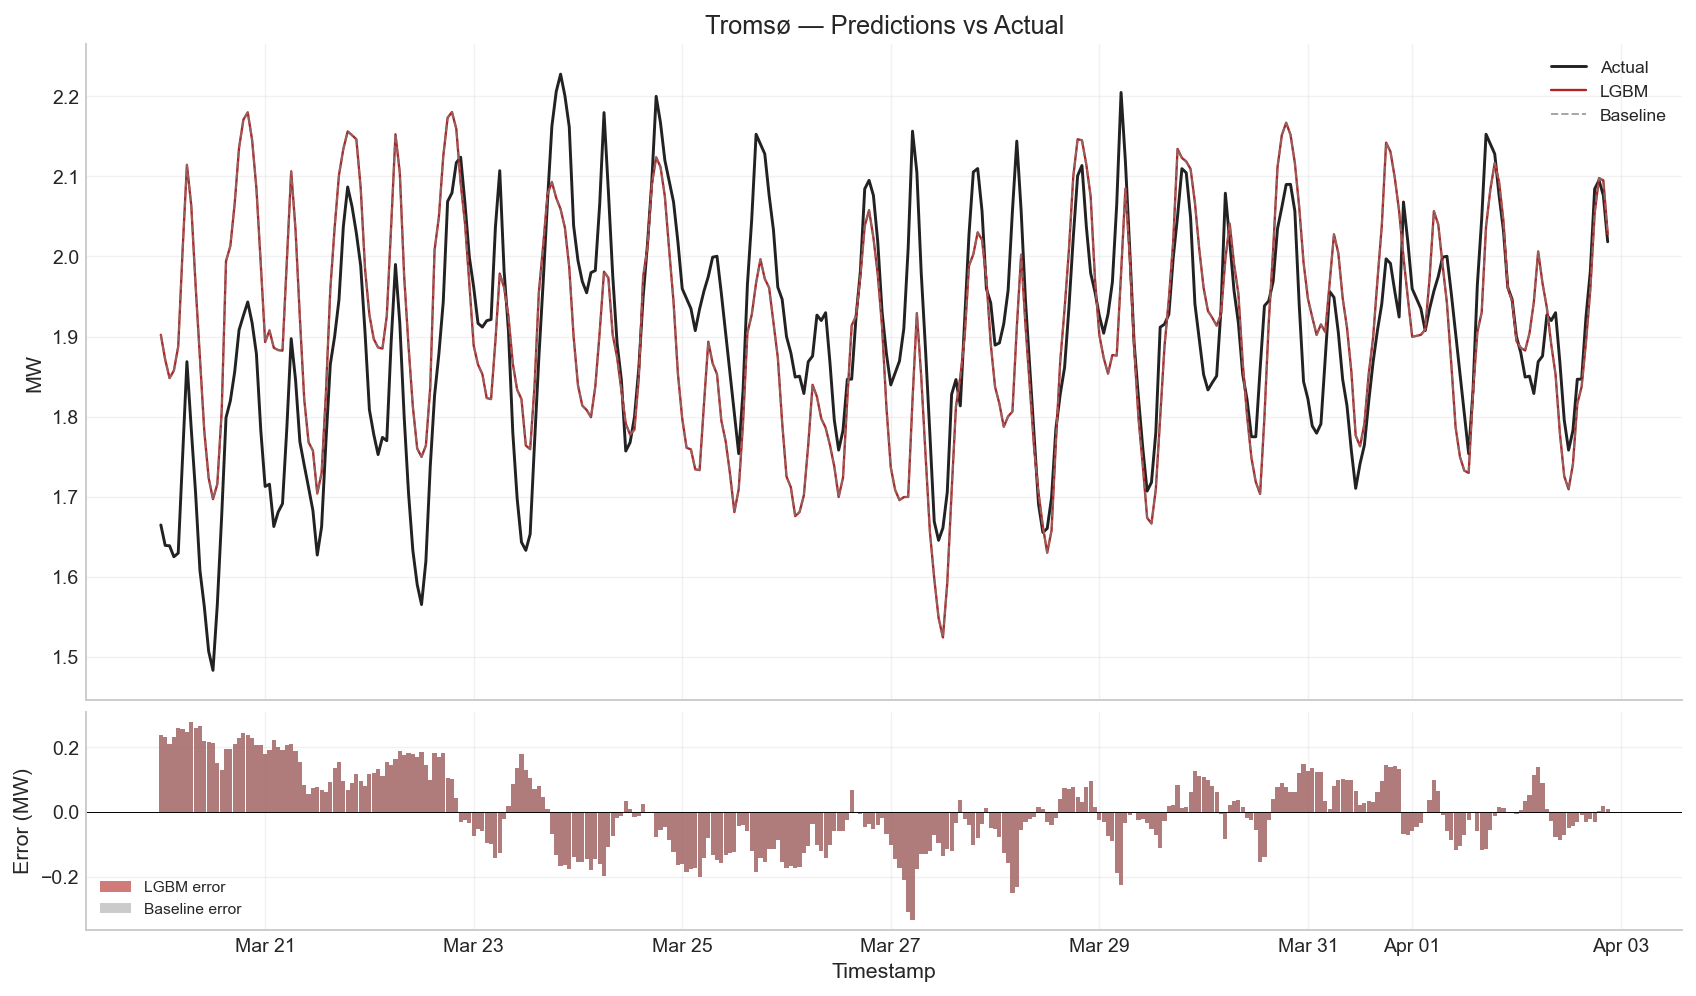

In [14]:
for focus_loc in ["oslo", "tromsø"]:
    lp = predictions[predictions["location"] == focus_loc].sort_values("timestamp")
    lb = baseline[baseline["location"] == focus_loc].sort_values("timestamp")

    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, constrained_layout=True,
                             gridspec_kw={"height_ratios": [3, 1]})

    # Top: actual vs predictions
    axes[0].plot(lp["timestamp"], lp["y_true_mw"], color="#222222", label="Actual", linewidth=1.5)
    axes[0].plot(lp["timestamp"], lp["y_pred_mw"], color="#b22222", label="LGBM", linewidth=1.2)
    axes[0].plot(lb["timestamp"], lb["y_pred"], color="#7f7f7f",
                 label="Baseline", linestyle="--", linewidth=1, alpha=0.7)
    axes[0].set_ylabel("MW")
    axes[0].set_title(f"{focus_loc.capitalize()} — Predictions vs Actual")
    axes[0].legend(fontsize=9)

    # Bottom: error
    err_model = lp["y_pred_mw"].values - lp["y_true_mw"].values
    err_base = lb["y_pred"].values - lb["y_true"].values
    axes[1].bar(lp["timestamp"], err_model, width=0.04, color="#b22222", alpha=0.6, label="LGBM error")
    axes[1].bar(lb["timestamp"], err_base, width=0.04, color="#7f7f7f", alpha=0.4, label="Baseline error")
    axes[1].axhline(0, color="black", linewidth=0.5)
    axes[1].set_ylabel("Error (MW)")
    axes[1].set_xlabel("Timestamp")
    axes[1].legend(fontsize=8)

    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    plt.savefig(f"deep_dive_{focus_loc}.png", bbox_inches="tight")
    plt.show()

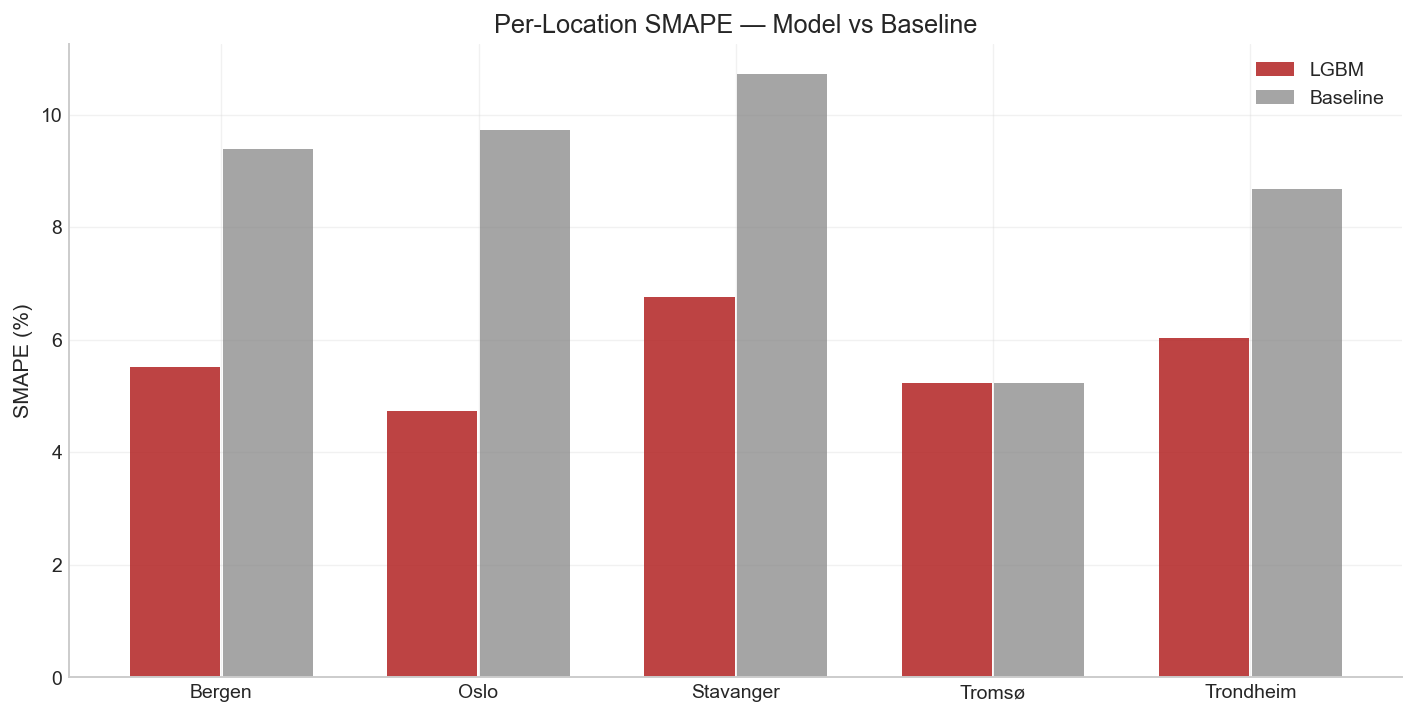

In [15]:
from collections import OrderedDict

def smape(y_true, y_pred, eps=1e-9):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    denom = np.maximum((np.abs(y_true) + np.abs(y_pred)) / 2.0, eps)
    return float(np.mean(np.abs(y_true - y_pred) / denom)) * 100.0

model_smapes, base_smapes = OrderedDict(), OrderedDict()
for loc in locations:
    lp = predictions[predictions["location"] == loc]
    lb = baseline[baseline["location"] == loc]
    model_smapes[loc] = smape(lp["y_true_mw"], lp["y_pred_mw"])
    base_smapes[loc] = smape(lb["y_true"], lb["y_pred"])

x = np.arange(len(locations))
fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
ax.bar(x - 0.18, list(model_smapes.values()), width=0.35,
       label="LGBM", color="#b22222", alpha=0.85)
ax.bar(x + 0.18, list(base_smapes.values()), width=0.35,
       label="Baseline", color="#7f7f7f", alpha=0.7)

ax.set_xticks(x)
ax.set_xticklabels([l.capitalize() for l in locations])
ax.set(ylabel="SMAPE (%)", title="Per-Location SMAPE — Model vs Baseline")
ax.legend()

plt.savefig("smape_by_location.png", bbox_inches="tight")
plt.show()

In [16]:
hels_pred = pd.read_csv("helsingfors_baseline_predictions.csv")
hels_pred["timestamp"] = pd.to_datetime(hels_pred["timestamp"])

print(f"Helsingfors baseline: {len(hels_pred)} rows")
print(f"Test window: {hels_pred['timestamp'].min().date()} → {hels_pred['timestamp'].max().date()}")

Helsingfors baseline: 334 rows
Test window: 2023-03-20 → 2023-04-02


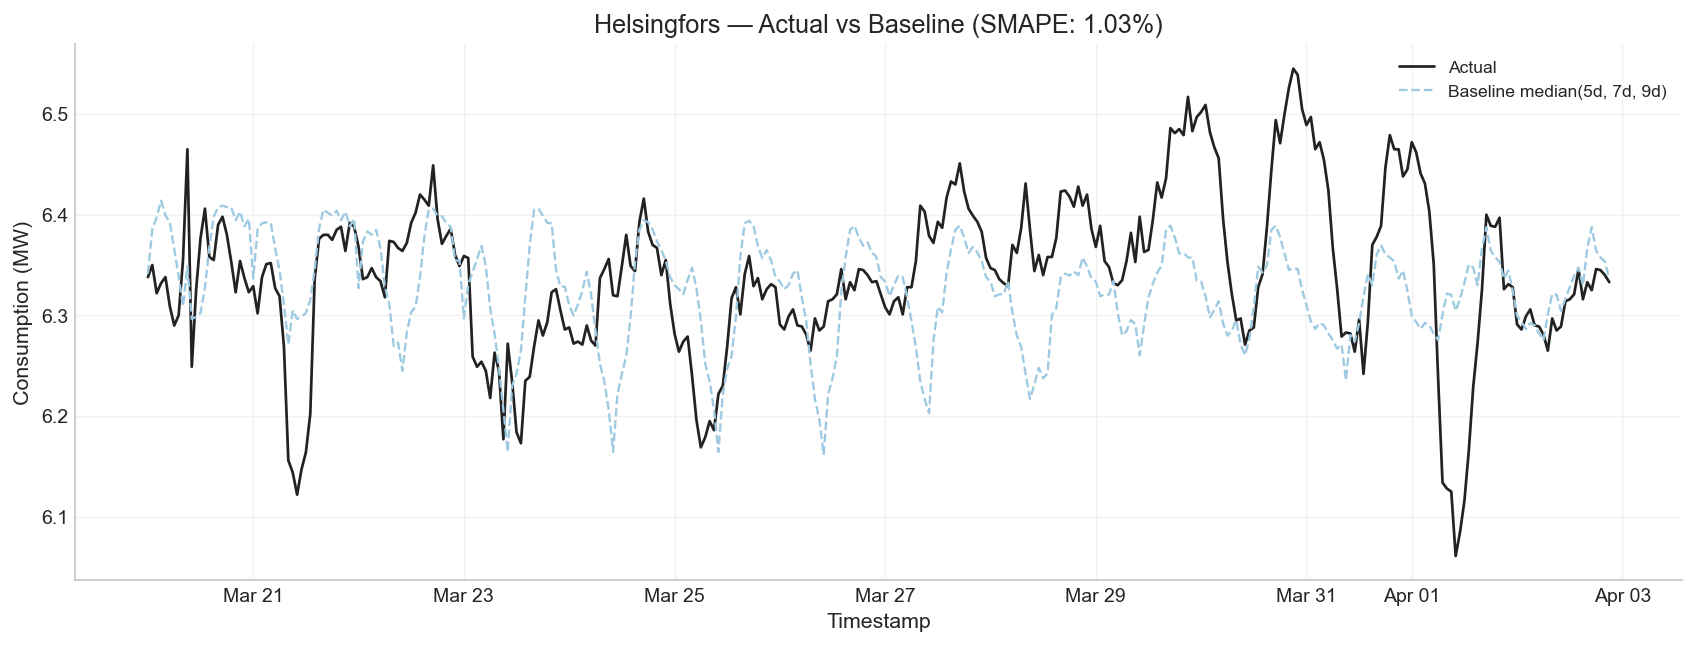

In [17]:
fig, ax = plt.subplots(figsize=(12, 4.5), constrained_layout=True)

ax.plot(hels_pred["timestamp"], hels_pred["y_true"], color="#222222",
        label="Actual", linewidth=1.4)
ax.plot(hels_pred["timestamp"], hels_pred["y_pred"], color="#9ecae1",
        label="Baseline median(5d, 7d, 9d)", linewidth=1.2, linestyle="--")

hels_smape = smape(hels_pred["y_true"], hels_pred["y_pred"])
ax.set(title=f"Helsingfors — Actual vs Baseline (SMAPE: {hels_smape:.2f}%)",
       xlabel="Timestamp", ylabel="Consumption (MW)")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

plt.savefig("helsingfors_baseline_test_window.png", bbox_inches="tight")
plt.show()

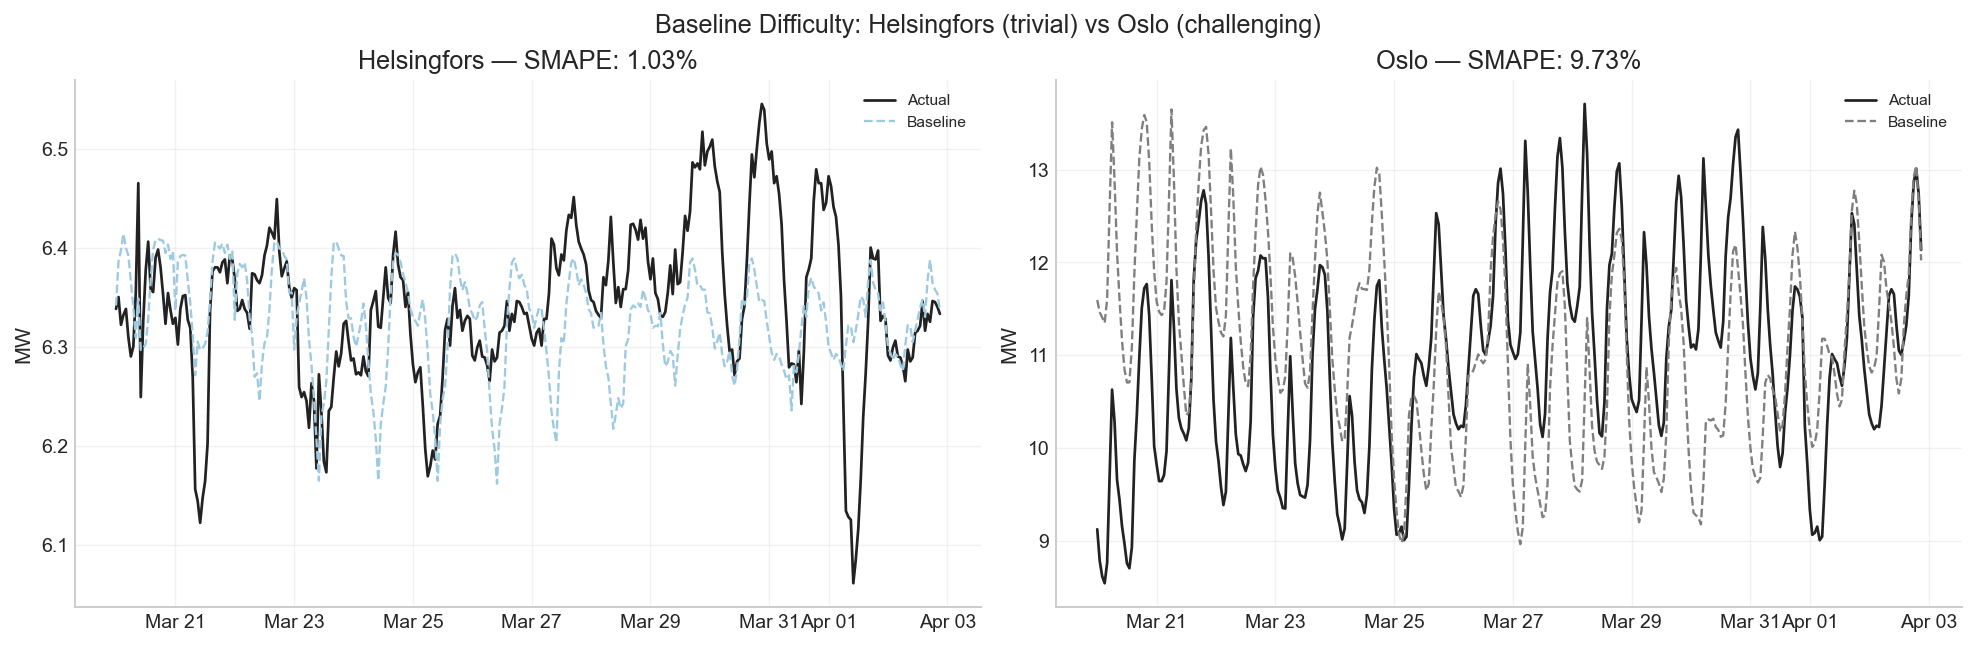

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)

# Helsingfors
ax = axes[0]
ax.plot(hels_pred["timestamp"], hels_pred["y_true"], color="#222222",
        label="Actual", linewidth=1.4)
ax.plot(hels_pred["timestamp"], hels_pred["y_pred"], color="#9ecae1",
        label="Baseline", linewidth=1.2, linestyle="--")
hels_s = smape(hels_pred["y_true"], hels_pred["y_pred"])
ax.set(title=f"Helsingfors — SMAPE: {hels_s:.2f}%", ylabel="MW")
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

# Oslo (hardest Norwegian location for the baseline)
ax = axes[1]
lo = predictions[predictions["location"] == "oslo"].sort_values("timestamp")
lb = baseline[baseline["location"] == "oslo"].sort_values("timestamp")
ax.plot(lo["timestamp"], lo["y_true_mw"], color="#222222",
        label="Actual", linewidth=1.4)
ax.plot(lb["timestamp"], lb["y_pred"], color="#7f7f7f",
        label="Baseline", linewidth=1.2, linestyle="--")
oslo_s = smape(lb["y_true"], lb["y_pred"])
ax.set(title=f"Oslo — SMAPE: {oslo_s:.2f}%", ylabel="MW")
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

plt.suptitle("Baseline Difficulty: Helsingfors (trivial) vs Oslo (challenging)", fontsize=13)
plt.savefig("helsingfors_vs_oslo_baseline.png", bbox_inches="tight")
plt.show()

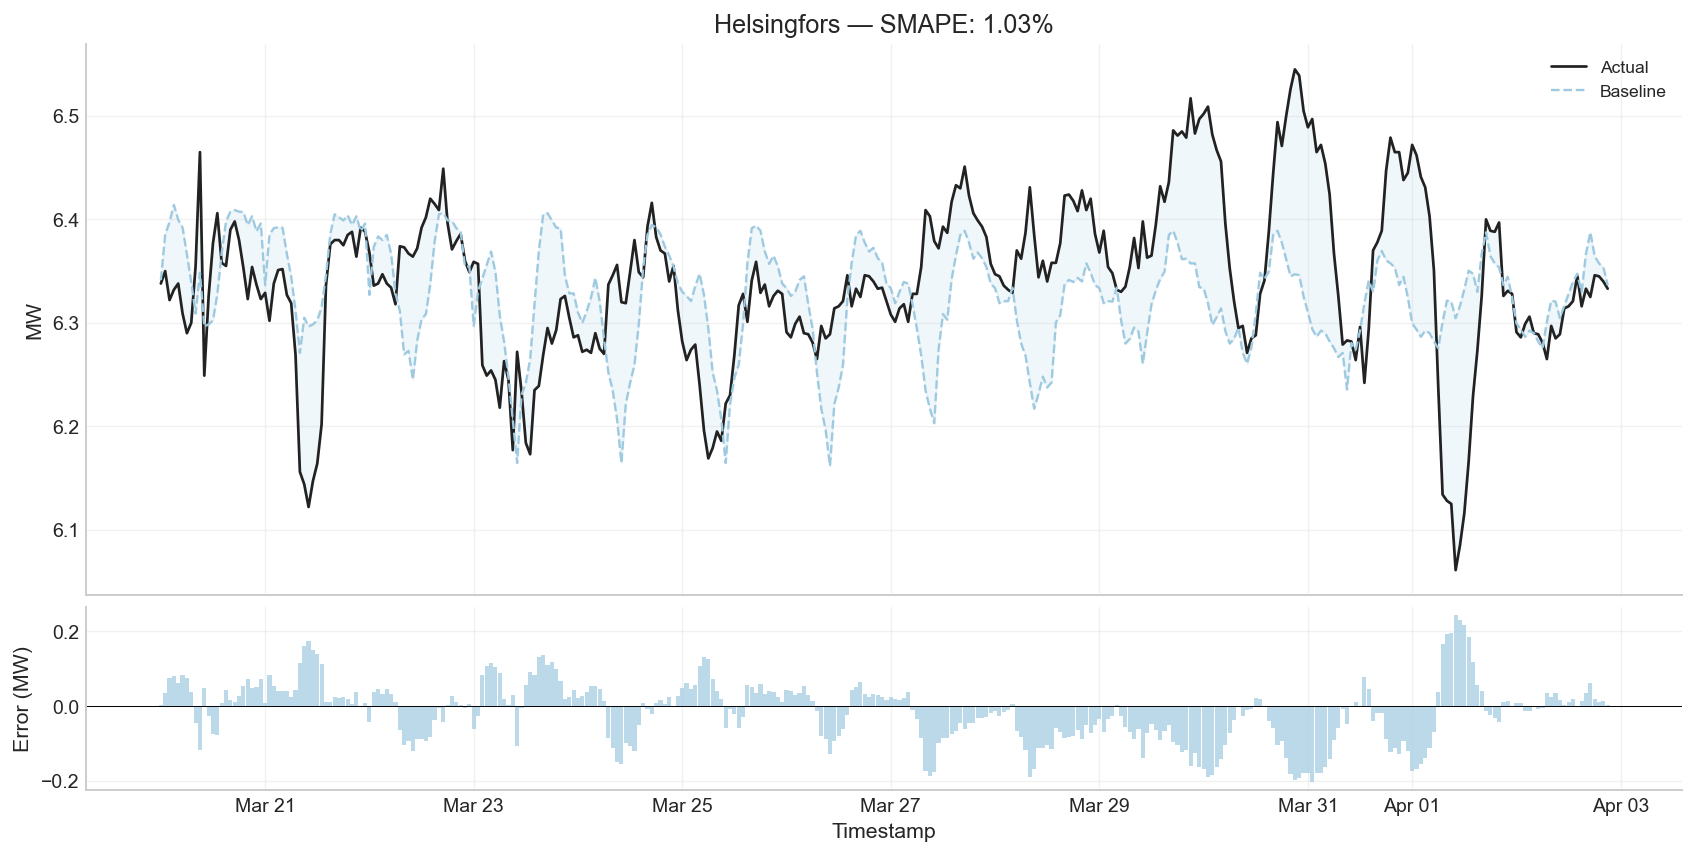

Helsingfors error stats:
  Mean error: -0.0151 MW
  Std error:  0.0829 MW
  Max |error|: 0.2435 MW


In [19]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True, constrained_layout=True,
                         gridspec_kw={"height_ratios": [3, 1]})

# Top: predictions
axes[0].plot(hels_pred["timestamp"], hels_pred["y_true"], color="#222222",
             label="Actual", linewidth=1.4)
axes[0].plot(hels_pred["timestamp"], hels_pred["y_pred"], color="#9ecae1",
             label="Baseline", linewidth=1.2, linestyle="--")
axes[0].fill_between(hels_pred["timestamp"],
                     hels_pred["y_true"], hels_pred["y_pred"],
                     color="#9ecae1", alpha=0.15)
axes[0].set(ylabel="MW", title=f"Helsingfors — SMAPE: {hels_smape:.2f}%")
axes[0].legend(fontsize=9)

# Bottom: error
err = hels_pred["y_pred"].values - hels_pred["y_true"].values
axes[1].bar(hels_pred["timestamp"], err, width=0.04, color="#9ecae1", alpha=0.7)
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].set(ylabel="Error (MW)", xlabel="Timestamp")

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.savefig("helsingfors_baseline_with_error.png", bbox_inches="tight")
plt.show()

print(f"Helsingfors error stats:")
print(f"  Mean error: {err.mean():.4f} MW")
print(f"  Std error:  {err.std():.4f} MW")
print(f"  Max |error|: {np.abs(err).max():.4f} MW")

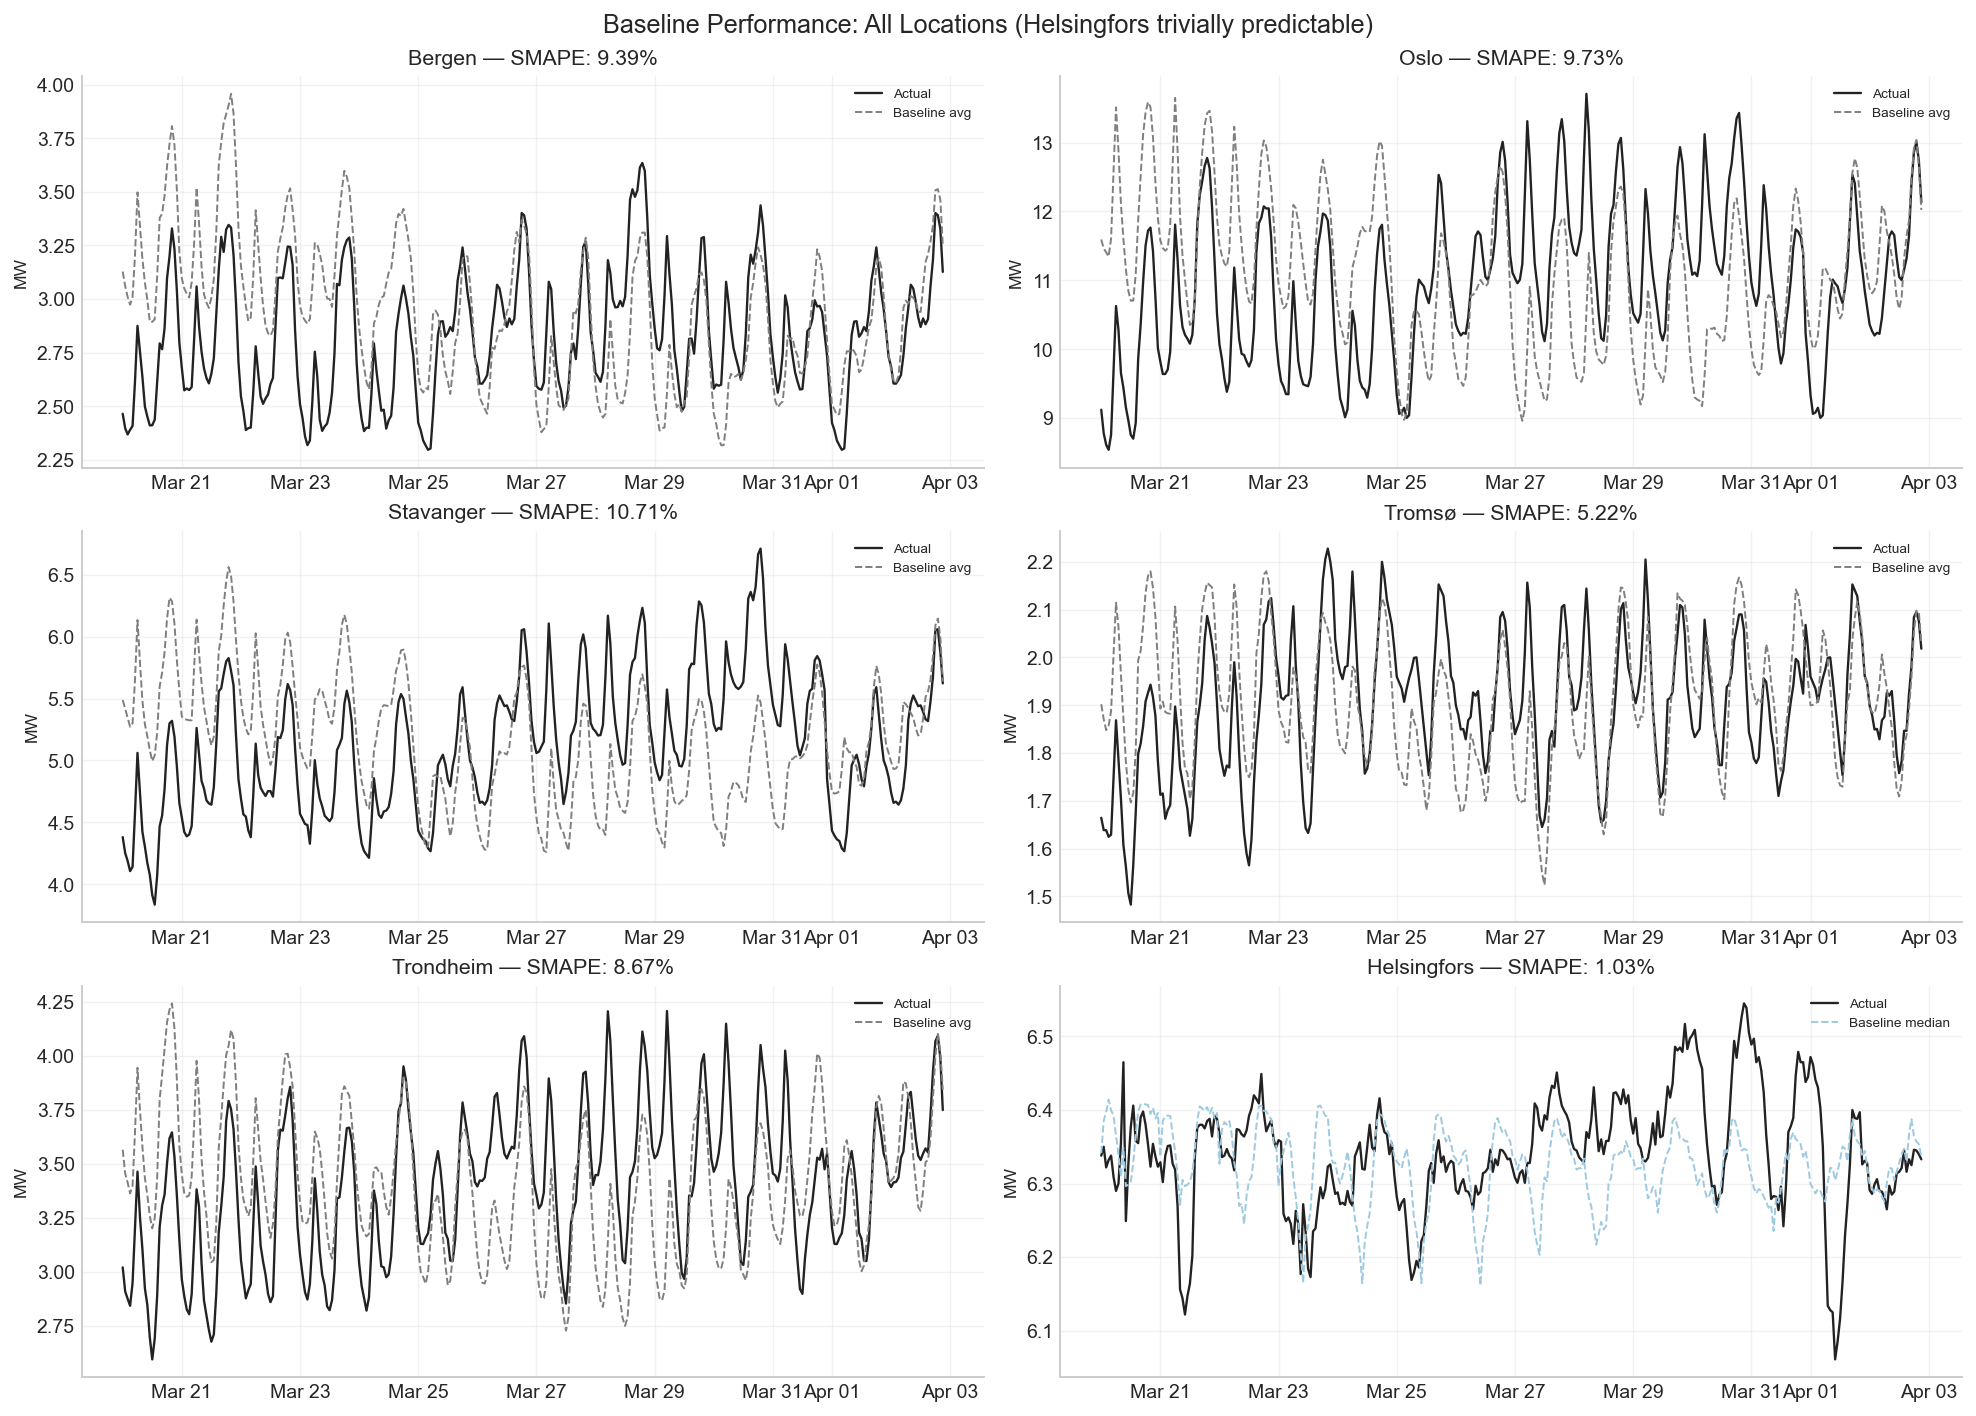

In [20]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10), constrained_layout=True)
axes = axes.flat

all_locs = locations + ["helsingfors"]

for ax, loc in zip(axes, all_locs):
    if loc == "helsingfors":
        ld = hels_pred.copy()
        true_col, pred_col = "y_true", "y_pred"
        color = "#9ecae1"
        base_label = "Baseline median"
    else:
        ld = baseline[baseline["location"] == loc].sort_values("timestamp")
        true_col, pred_col = "y_true", "y_pred"
        lp = predictions[predictions["location"] == loc].sort_values("timestamp")
        color = "#7f7f7f"
        base_label = "Baseline avg"

    ax.plot(ld["timestamp"], ld[true_col], color="#222222", linewidth=1.2, label="Actual")
    ax.plot(ld["timestamp"], ld[pred_col], color=color,
            linewidth=1, linestyle="--", label=base_label)

    loc_s = smape(ld[true_col], ld[pred_col])
    ax.set_title(f"{loc.capitalize()} — SMAPE: {loc_s:.2f}%", fontsize=11)
    ax.set_ylabel("MW", fontsize=9)
    ax.legend(fontsize=7, loc="upper right")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

# Hide unused subplot if odd number
if len(all_locs) < len(list(axes)):
    for j in range(len(all_locs), len(list(axes))):
        axes[j].set_visible(False)

plt.suptitle("Baseline Performance: All Locations (Helsingfors trivially predictable)", fontsize=13)
plt.savefig("all_locations_baseline_comparison.png", bbox_inches="tight")
plt.show()

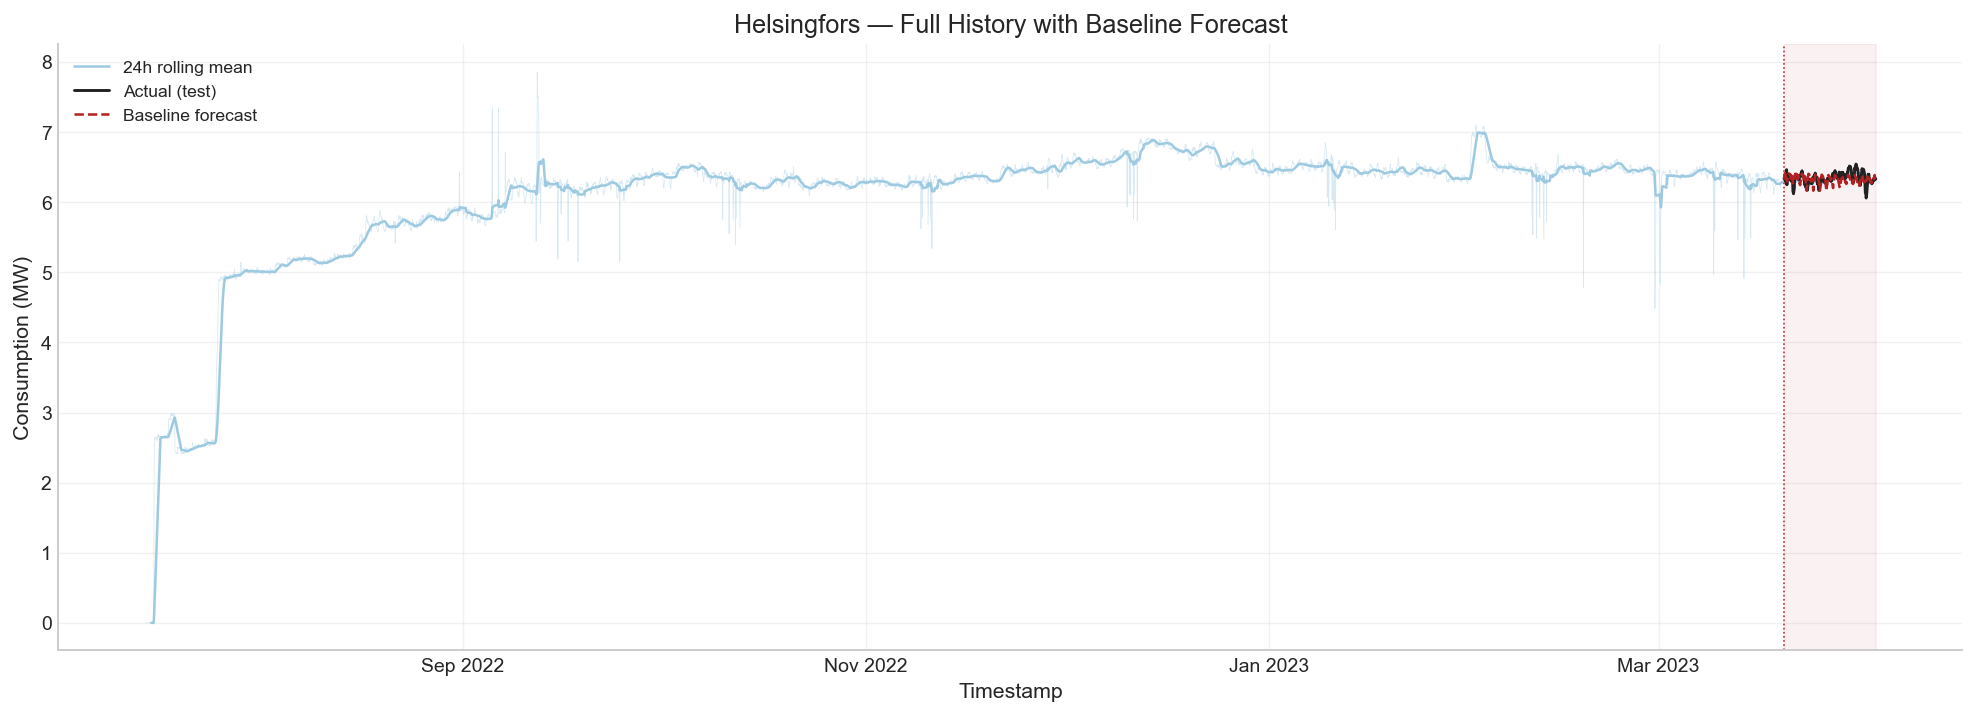

In [21]:
hels_raw = raw[raw["location"] == "helsingfors"].sort_values("time")
hels_test_start = hels_pred["timestamp"].min()
hels_test_end = hels_pred["timestamp"].max()

fig, ax = plt.subplots(figsize=(14, 5), constrained_layout=True)

# Full history — raw hourly (faded)
ax.plot(hels_raw["time"], hels_raw["consumption"], color="#9ecae1",
        linewidth=0.4, alpha=0.4)

# Full history — 24h rolling mean
daily = hels_raw.set_index("time")["consumption"].rolling(24).mean()
ax.plot(daily.index, daily.values, color="#9ecae1", linewidth=1.3, label="24h rolling mean")

# Test window predictions
ax.plot(hels_pred["timestamp"], hels_pred["y_true"], color="#222222",
        linewidth=1.5, label="Actual (test)")
ax.plot(hels_pred["timestamp"], hels_pred["y_pred"], color="#b22222",
        linewidth=1.3, linestyle="--", label="Baseline forecast")

# Highlight test window
ax.axvspan(hels_test_start, hels_test_end, color="#b22222", alpha=0.06)
ax.axvline(hels_test_start, color="#b22222", linestyle=":", linewidth=0.8)

ax.set(title="Helsingfors — Full History with Baseline Forecast",
       xlabel="Timestamp", ylabel="Consumption (MW)")
ax.legend(fontsize=9, loc="upper left")
ax.xaxis.set_major_locator(month_locator)
ax.xaxis.set_major_formatter(month_fmt)

plt.savefig("helsingfors_full_history.png", bbox_inches="tight")
plt.show()

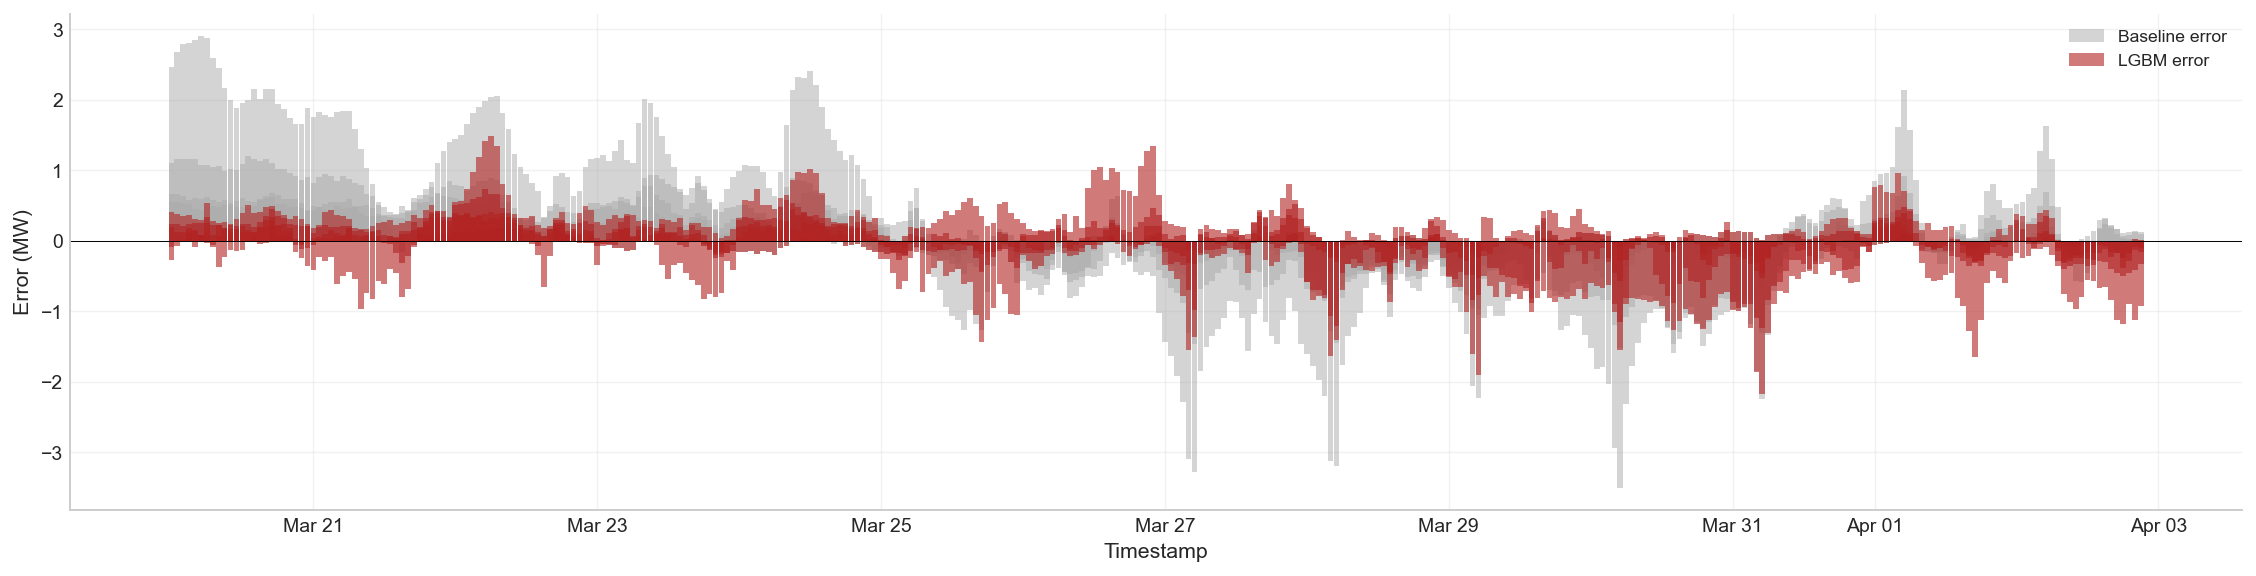

LGBM   — mean: -0.0311 MW, std: 0.3803 MW
Baseline — mean: +0.0535 MW, std: 0.6778 MW


In [22]:
pred_sorted = predictions.sort_values("timestamp")
base_sorted = baseline.sort_values("timestamp")

err_model = pred_sorted["y_pred_mw"].values - pred_sorted["y_true_mw"].values
err_base = base_sorted["y_pred"].values - base_sorted["y_true"].values

fig, ax = plt.subplots(figsize=(16, 4), constrained_layout=True)

ax.bar(base_sorted["timestamp"], err_base, width=0.04,
       color="#AAAAAA", alpha=0.5, label="Baseline error")
ax.bar(pred_sorted["timestamp"], err_model, width=0.04,
       color="#b22222", alpha=0.6, label="LGBM error")
ax.axhline(0, color="black", linewidth=0.5)

ax.set(xlabel="Timestamp", ylabel="Error (MW)")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

plt.savefig("overall_error_timeline.png", bbox_inches="tight")
plt.show()

print(f"LGBM   — mean: {err_model.mean():+.4f} MW, std: {np.std(err_model):.4f} MW")
print(f"Baseline — mean: {err_base.mean():+.4f} MW, std: {np.std(err_base):.4f} MW")

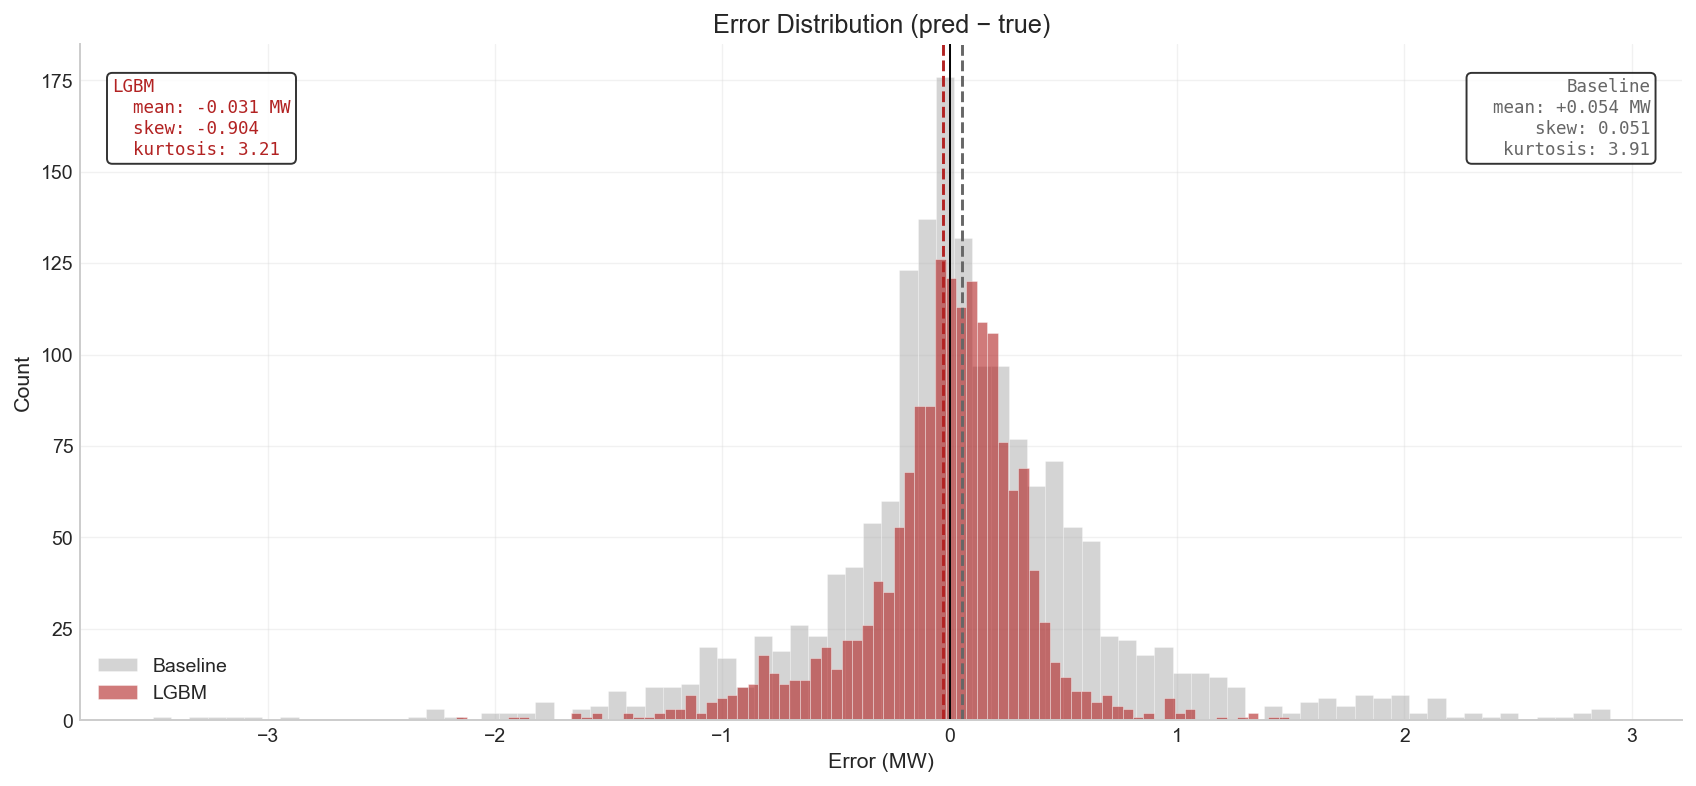

In [23]:
model_skew = pd.Series(err_model).skew()
model_kurt = pd.Series(err_model).kurtosis()
base_skew = pd.Series(err_base).skew()
base_kurt = pd.Series(err_base).kurtosis()

fig, ax = plt.subplots(figsize=(12, 5.5), constrained_layout=True)

ax.hist(err_base, bins=80, color="#AAAAAA", alpha=0.5, edgecolor="white",
        linewidth=0.3, label="Baseline")
ax.hist(err_model, bins=80, color="#b22222", alpha=0.6, edgecolor="white",
        linewidth=0.3, label="LGBM")

ax.axvline(0, color="black", linewidth=1)
ax.axvline(np.mean(err_model), color="#b22222", linewidth=1.5, linestyle="--")
ax.axvline(np.mean(err_base), color="#666666", linewidth=1.5, linestyle="--")

ax.set(title="Error Distribution (pred − true)", xlabel="Error (MW)", ylabel="Count")

# Stats labels
ax.text(0.02, 0.95,
        f"LGBM\n"
        f"  mean: {np.mean(err_model):+.3f} MW\n"
        f"  skew: {model_skew:.3f}\n"
        f"  kurtosis: {model_kurt:.2f}",
        transform=ax.transAxes, fontsize=9, verticalalignment="top",
        color="#b22222", family="monospace",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

ax.text(0.98, 0.95,
        f"Baseline\n"
        f"  mean: {np.mean(err_base):+.3f} MW\n"
        f"  skew: {base_skew:.3f}\n"
        f"  kurtosis: {base_kurt:.2f}",
        transform=ax.transAxes, fontsize=9, verticalalignment="top",
        horizontalalignment="right", color="#666666", family="monospace",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

ax.legend(fontsize=10)

plt.savefig("error_distribution.png", bbox_inches="tight")
plt.show()

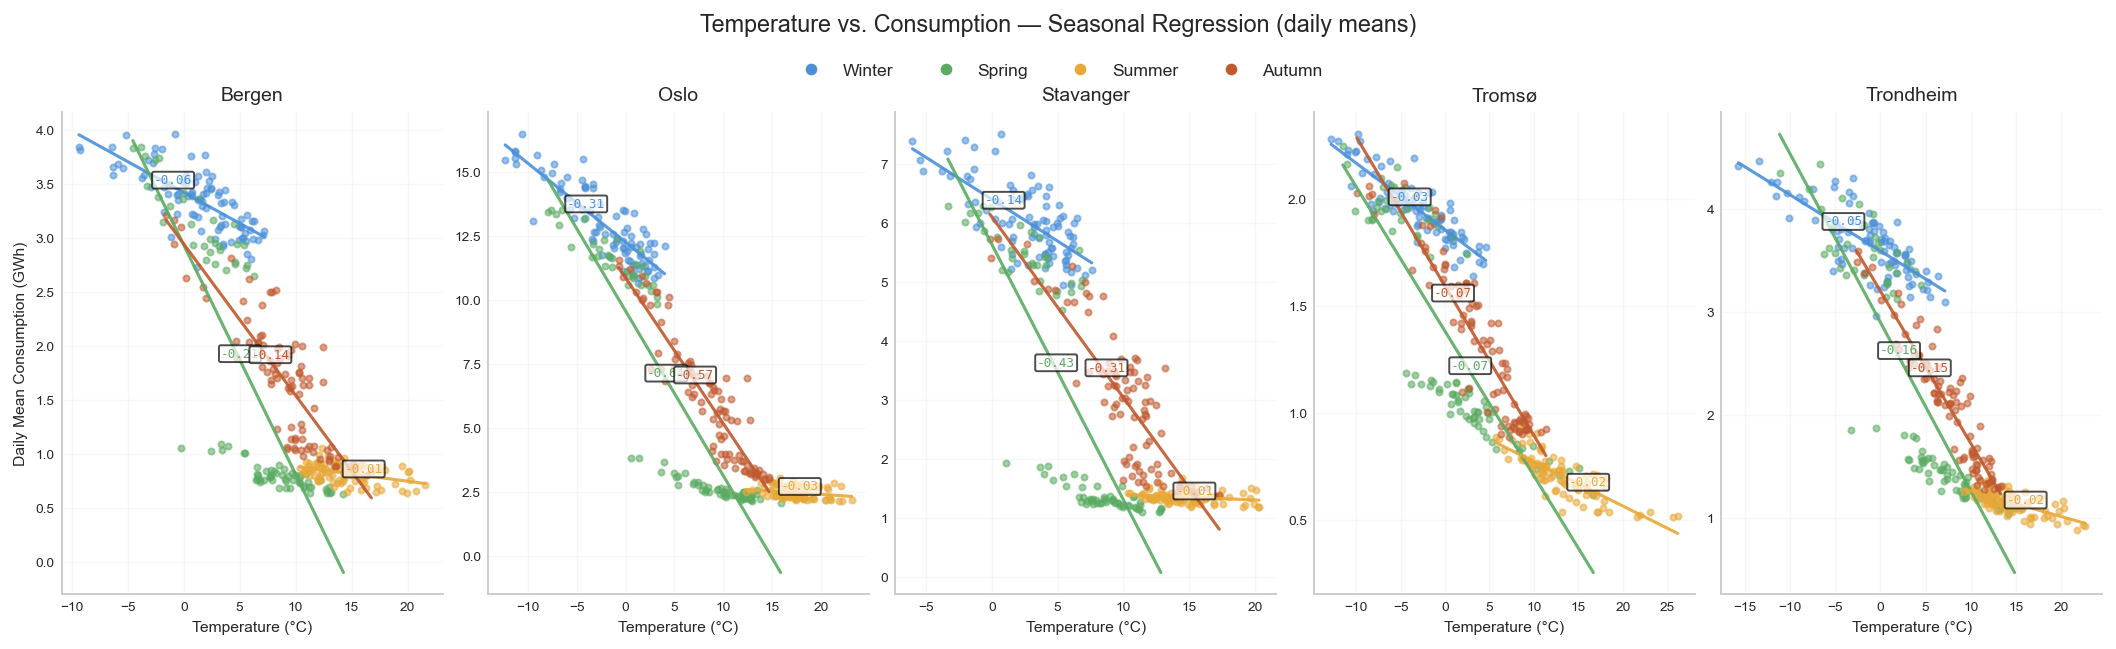

In [24]:
# ── Temperature vs. Consumption: seasonal scatter with regression ──────────────
LOCS = ["bergen", "oslo", "stavanger", "tromsø", "trondheim"]

season_map = {12: "Winter", 1: "Winter", 2: "Winter",
              3: "Spring", 4: "Spring", 5: "Spring",
              6: "Summer", 7: "Summer", 8: "Summer",
              9: "Autumn", 10: "Autumn", 11: "Autumn"}

season_colors = {
    "Winter": "#4a90d9",   # cold blue
    "Spring": "#5aab61",   # green
    "Summer": "#e8a838",   # warm amber
    "Autumn": "#c0592e",   # burnt orange
}
season_order = ["Winter", "Spring", "Summer", "Autumn"]

df_5 = df[df["location"].isin(LOCS)].copy()
df_5["season"] = df_5["time"].dt.month.map(season_map)

# Daily aggregation reduces overplotting and noise from diurnal cycle
daily = (
    df_5.groupby(["location", "season",
                  pd.Grouper(key="time", freq="D")], as_index=False)
    [["consumption", "temperature"]].mean()
)

fig, axes = plt.subplots(1, len(LOCS), figsize=(15, 4),
                         constrained_layout=True, sharey=False)

for ax, loc in zip(axes, LOCS):
    sub = daily[daily["location"] == loc]
    for season in season_order:
        s = sub[sub["season"] == season]
        ax.scatter(s["temperature"], s["consumption"],
                   s=10, alpha=0.55, color=season_colors[season],
                   label=season, rasterized=True)
        # regression line per season
        if len(s) > 5:
            m, b = np.polyfit(s["temperature"], s["consumption"], 1)
            x_range = np.linspace(s["temperature"].min(), s["temperature"].max(), 60)
            ax.plot(x_range, m * x_range + b,
                    color=season_colors[season], linewidth=1.6, alpha=0.9)
            # annotate slope
            x_mid = x_range[30]
            y_mid = m * x_mid + b
            ax.text(x_mid, y_mid, f"{m:+.2f}", fontsize=6.5,
                    color=season_colors[season], family="monospace",
                    ha="center", va="bottom",
                    bbox=dict(boxstyle="round,pad=0.15", facecolor="white", alpha=0.7))

    ax.set_title(loc.capitalize(), fontsize=10)
    ax.set_xlabel("Temperature (°C)", fontsize=8)
    ax.grid(True, alpha=0.2)
    ax.tick_params(labelsize=7)

axes[0].set_ylabel("Daily Mean Consumption (GWh)", fontsize=8)

handles = [plt.Line2D([0], [0], marker="o", color="w",
                       markerfacecolor=season_colors[s], markersize=7, label=s)
           for s in season_order]
fig.legend(handles=handles, ncol=4, loc="upper center",
           bbox_to_anchor=(0.5, 1.06), frameon=False, fontsize=9)

fig.suptitle("Temperature vs. Consumption — Seasonal Regression (daily means)",
             y=1.12, fontsize=12)

plt.savefig("temp_consumption_seasonal.png", bbox_inches="tight")
plt.show()

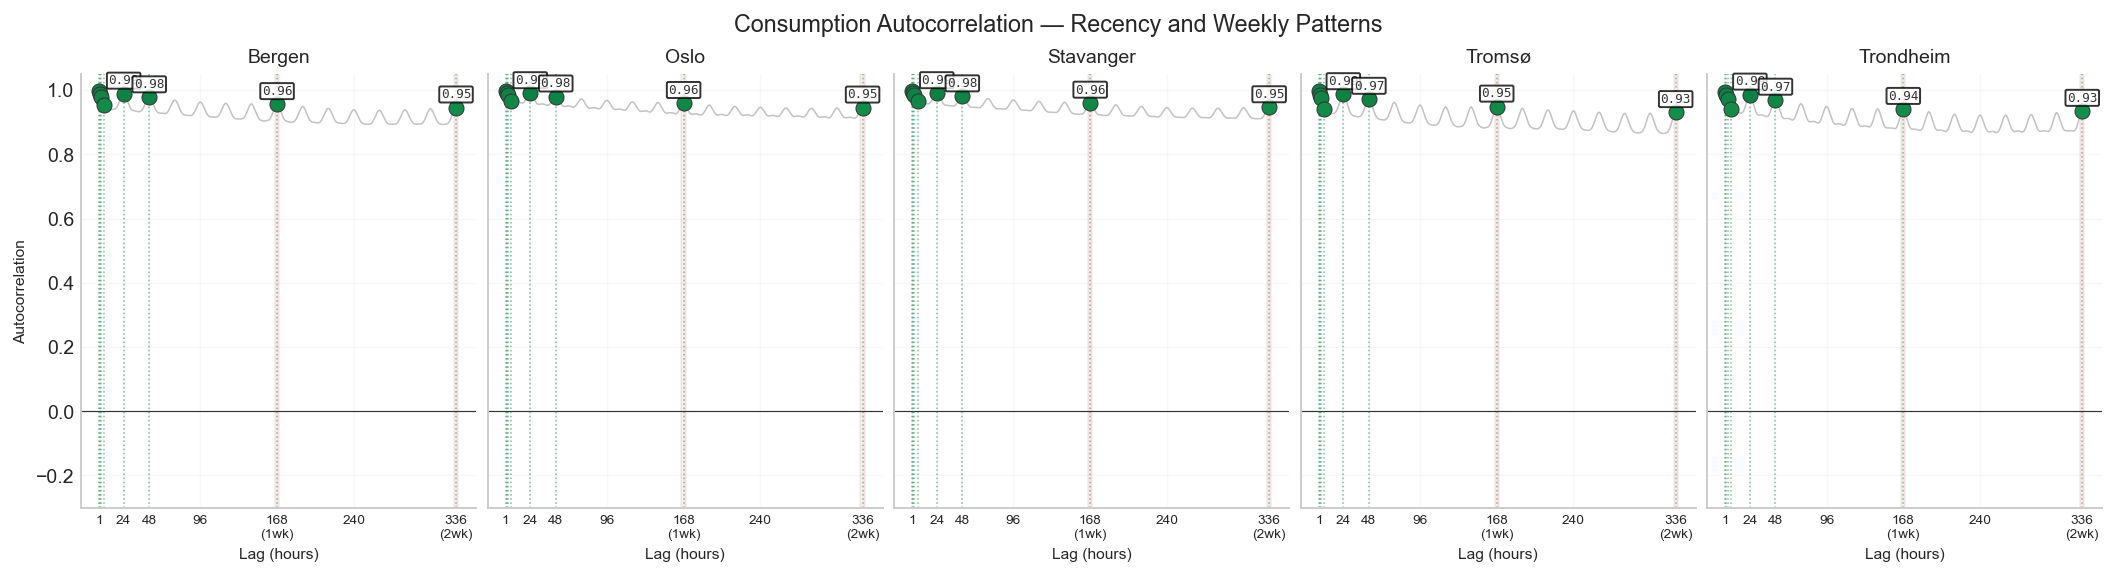

In [25]:
# ── Consumption lag correlations — recency + weekday patterns ──────────────────
# Lags in hours: recent (1–6h), same-time-yesterday (24h), ±1h around yesterday,
# 48h, weekday echoes (168h = 1 week, 336h = 2 weeks)
HIGHLIGHT_LAGS = {
    1:   "Lag 1h\n(recency)",
    2:   "Lag 2h",
    3:   "Lag 3h",
    6:   "Lag 6h",
    24:  "Lag 24h\n(yesterday)",
    48:  "Lag 48h\n(2 days)",
    168: "Lag 168h\n(1 week)",
    336: "Lag 336h\n(2 weeks)",
}
ALL_LAGS = list(range(1, 337))   # 1–336 hours for the background line

LOCS = ["bergen", "oslo", "stavanger", "tromsø", "trondheim"]

df_5 = df[df["location"].isin(LOCS)].copy().sort_values(["location", "time"])

fig, axes = plt.subplots(1, len(LOCS), figsize=(15, 4),
                         constrained_layout=True, sharey=True)

for ax, loc in zip(axes, LOCS):
    series = (df_5[df_5["location"] == loc]
              .set_index("time")["consumption"]
              .asfreq("h"))      # ensure regular hourly index

    # Full lag correlation profile (background)
    corrs_all = [series.autocorr(lag=k) for k in ALL_LAGS]
    ax.plot(ALL_LAGS, corrs_all, color="#aaaaaa", linewidth=0.8,
            alpha=0.7, zorder=1)
    ax.axhline(0, color="#333333", linewidth=0.6)

    # Highlight specific lags with coloured dots + labels
    cmap = plt.get_cmap("RdYlGn")
    for lag, label in HIGHLIGHT_LAGS.items():
        c = series.autocorr(lag=lag)
        # colour encodes correlation strength: green = strong positive, red = negative
        dot_color = cmap(0.5 + c * 0.45)
        ax.scatter(lag, c, s=60, color=dot_color,
                   edgecolors="#333333", linewidths=0.5, zorder=3)
        # vertical dashed guide
        ax.axvline(lag, color=dot_color, linewidth=0.8, linestyle=":", alpha=0.5, zorder=2)
        # value label (skip crowded early lags)
        if lag >= 24:
            ax.text(lag, c + 0.03, f"{c:.2f}", fontsize=6.5,
                    ha="center", color="#333333", family="monospace",
                    bbox=dict(boxstyle="round,pad=0.12", facecolor="white", alpha=0.8))

    # Band-shade week boundaries
    for w in [168, 336]:
        ax.axvspan(w - 2, w + 2, color="#b22222", alpha=0.07)

    ax.set_title(loc.capitalize(), fontsize=10)
    ax.set_xlabel("Lag (hours)", fontsize=8)
    ax.set_xticks([1, 24, 48, 96, 168, 240, 336])
    ax.set_xticklabels(["1", "24", "48", "96", "168\n(1wk)", "240", "336\n(2wk)"],
                       fontsize=7)
    ax.set_ylim(-0.3, 1.05)
    ax.grid(True, alpha=0.2)

axes[0].set_ylabel("Autocorrelation", fontsize=8)
fig.suptitle("Consumption Autocorrelation — Recency and Weekly Patterns",
             fontsize=12)

plt.savefig("consumption_lag_correlation.png", bbox_inches="tight")
plt.show()

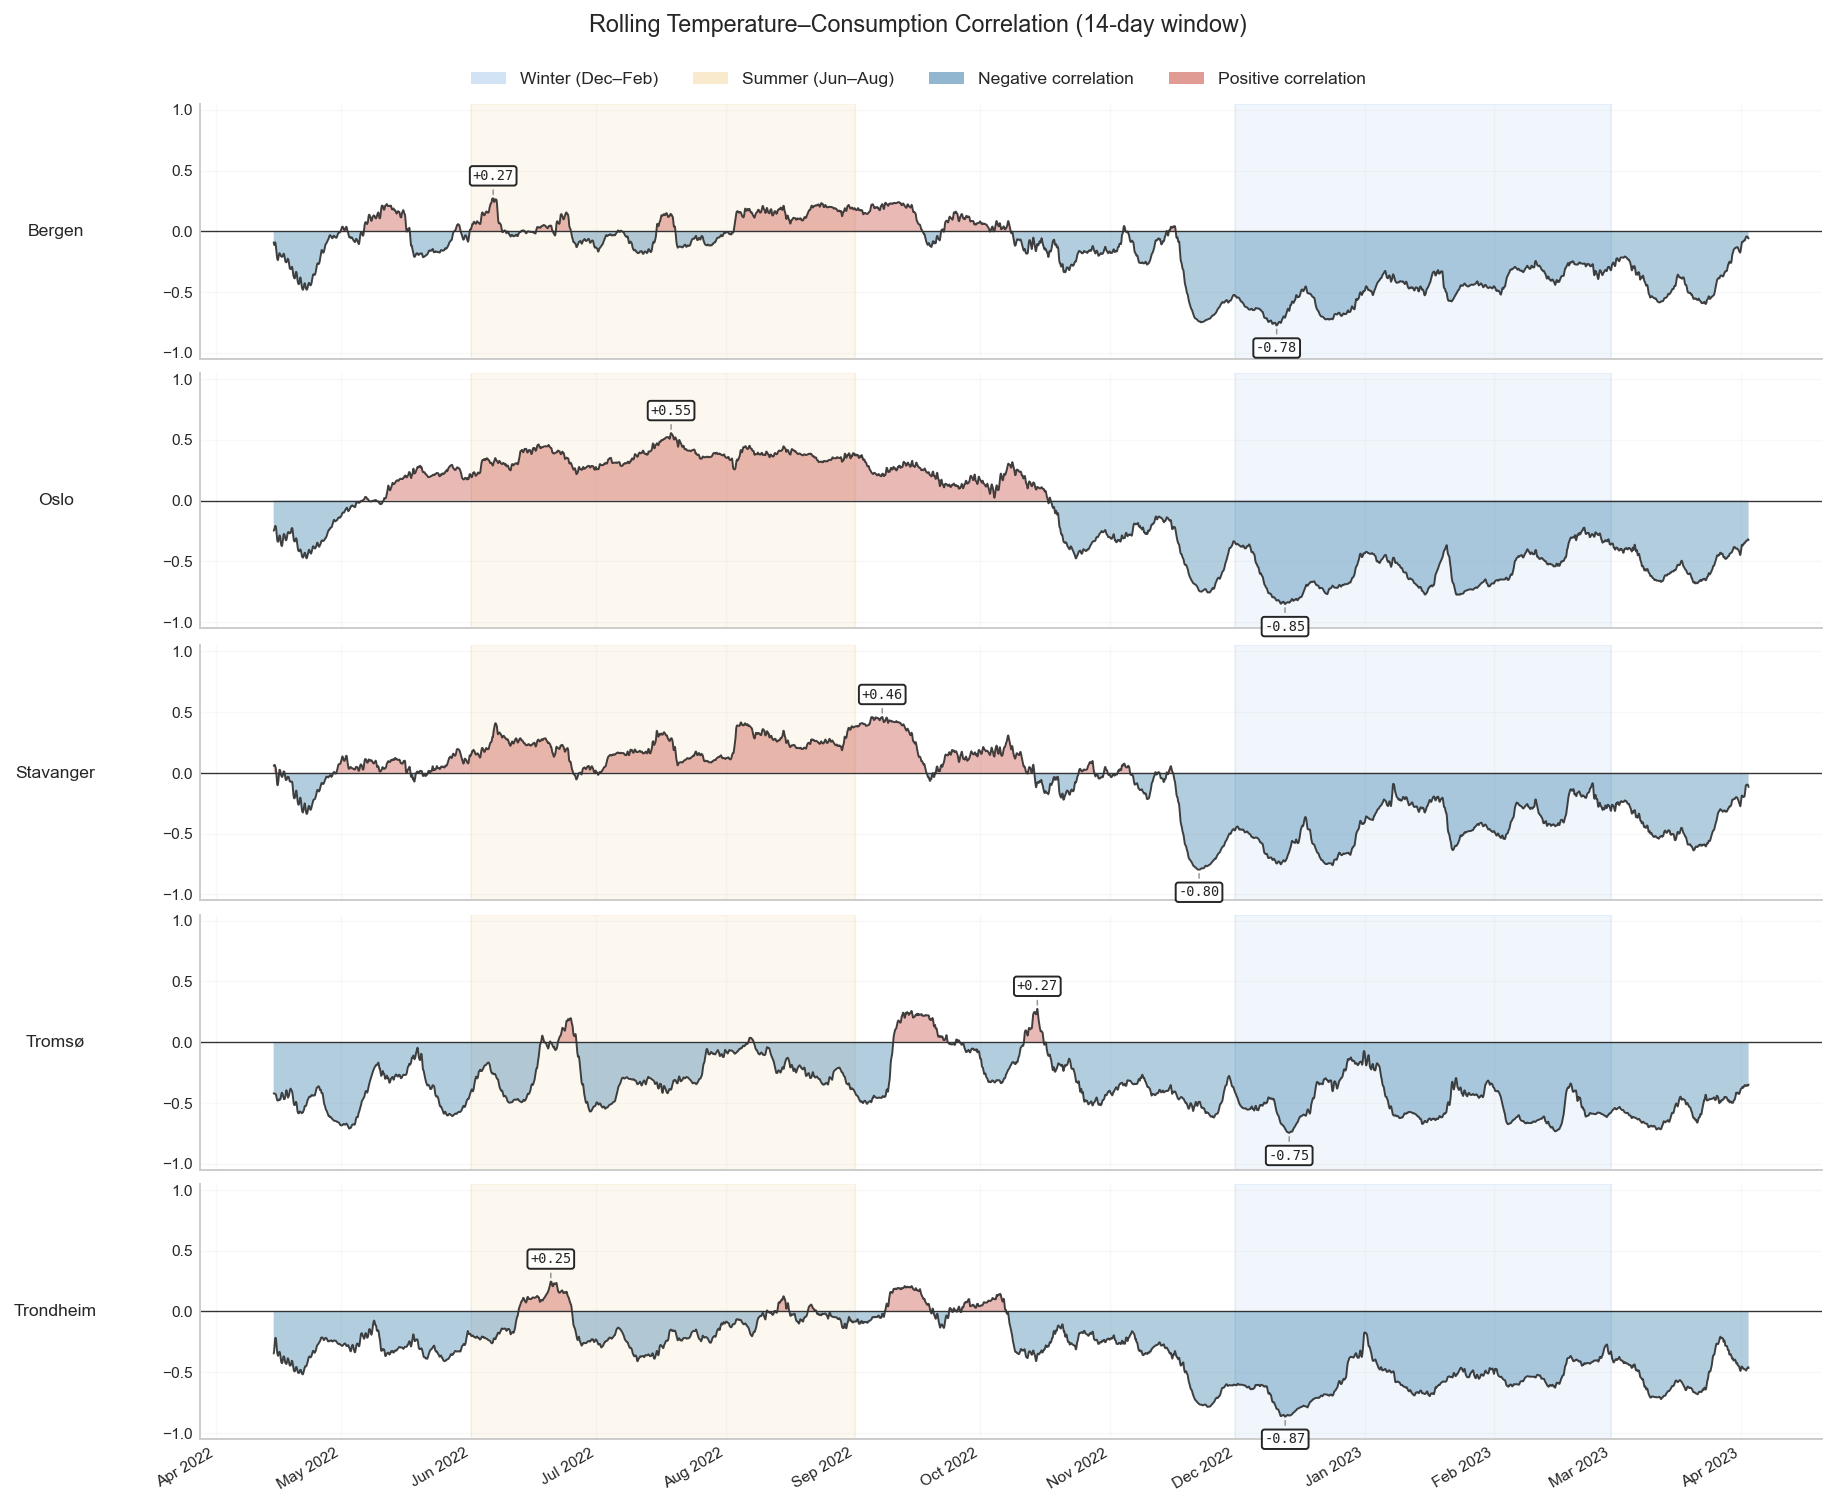

In [31]:
# ── Rolling temperature–consumption correlation over time ──────────────────────
# A 14-day (336h) rolling window captures the local linear relationship
# without smoothing away seasonal transitions.

WINDOW_HOURS = 336   # 14 days
LOCS = ["bergen", "oslo", "stavanger", "tromsø", "trondheim"]

df_5 = df[df["location"].isin(LOCS)].copy().sort_values(["location", "time"])

fig, axes = plt.subplots(len(LOCS), 1, figsize=(13, 10),
                         constrained_layout=True, sharex=True)

# Shade the four seasons consistently across all panels
def shade_seasons(ax, times):
    t_min, t_max = times.min(), times.max()
    years = times.dt.year.unique()
    for yr in years:
        summer_start = pd.Timestamp(f"{yr}-06-01")
        summer_end   = pd.Timestamp(f"{yr}-09-01")
        winter_start = pd.Timestamp(f"{yr}-12-01")
        winter_end   = pd.Timestamp(f"{yr+1}-03-01")

        # Clip each band to the actual data extent before drawing
        if summer_start < t_max and summer_end > t_min:
            ax.axvspan(max(summer_start, t_min), min(summer_end, t_max),
                       color="#e8a838", alpha=0.08, zorder=0)
        if winter_start < t_max and winter_end > t_min:
            ax.axvspan(max(winter_start, t_min), min(winter_end, t_max),
                       color="#4a90d9", alpha=0.08, zorder=0)

for ax, loc in zip(axes, LOCS):
    sub = (df_5[df_5["location"] == loc]
           .set_index("time")[["consumption", "temperature"]]
           .asfreq("h"))

    rolling_corr = (sub["consumption"]
                    .rolling(WINDOW_HOURS, min_periods=WINDOW_HOURS // 2)
                    .corr(sub["temperature"]))

    shade_seasons(ax, sub.reset_index()["time"])

    # Fill above/below zero to make sign immediately readable
    ax.fill_between(rolling_corr.index, rolling_corr, 0,
                    where=(rolling_corr >= 0),
                    color="#c0392b", alpha=0.35, linewidth=0, label="Positive")
    ax.fill_between(rolling_corr.index, rolling_corr, 0,
                    where=(rolling_corr < 0),
                    color="#2471a3", alpha=0.35, linewidth=0, label="Negative")
    ax.plot(rolling_corr.index, rolling_corr,
            color="#222222", linewidth=1.0, alpha=0.85)

    ax.axhline(0, color="#333333", linewidth=0.7)
    ax.set_ylim(-1.05, 1.05)
    ax.set_yticks([-1, -0.5, 0, 0.5, 1])
    ax.set_ylabel(loc.capitalize(), fontsize=9, rotation=0,
                  labelpad=55, va="center")
    ax.grid(True, alpha=0.18)
    ax.tick_params(labelsize=8)

    # Annotate min/max with their dates
    valid = rolling_corr.dropna()
    for val, func, va in [(valid.min(), valid.idxmin, "top"),
                          (valid.max(), valid.idxmax, "bottom")]:
        t = func()
        ax.annotate(f"{val:+.2f}",
                    xy=(t, val), xytext=(0, 8 if va == "bottom" else -8),
                    textcoords="offset points", ha="center", va=va,
                    fontsize=7, family="monospace", color="#222222",
                    bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.85),
                    arrowprops=dict(arrowstyle="-", color="#999999", lw=0.8))

# Shared x-axis formatting
axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.setp(axes[-1].get_xticklabels(), rotation=30, ha="right", fontsize=8)

# Season legend patches + correlation sign legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#4a90d9", alpha=0.25, label="Winter (Dec–Feb)"),
    Patch(facecolor="#e8a838", alpha=0.25, label="Summer (Jun–Aug)"),
    Patch(facecolor="#2471a3", alpha=0.5,  label="Negative correlation"),
    Patch(facecolor="#c0392b", alpha=0.5,  label="Positive correlation"),
]
fig.legend(handles=legend_elements, ncol=4, loc="upper center",
           bbox_to_anchor=(0.5, 1.03), frameon=False, fontsize=9)

fig.suptitle(
    f"Rolling Temperature–Consumption Correlation ({WINDOW_HOURS // 24}-day window)",
    fontsize=12, y=1.06
)

plt.savefig("rolling_temp_correlation.png", bbox_inches="tight")
plt.show()